# 1.Shot-Process Decomposition and Difference-Based Feature Design

## 1. Motivation

The derived variables are not included merely to increase the number of available features. Their purpose is to decompose the goal-scoring process into three conceptually distinct stages:

1. **Shot generation**
2. **Shot accuracy**
3. **Finishing efficiency**

The decomposition is based on the following exact identity:

$$
\mathrm{Goals}
=
\mathrm{Shots}
\times
\frac{\mathrm{Shots\ on\ Target}}{\mathrm{Shots}}
\times
\frac{\mathrm{Goals}}{\mathrm{Shots\ on\ Target}}
$$

Equivalently,

$$
\frac{\mathrm{Goals}}{\mathrm{Shots}}
=
\frac{\mathrm{Shots\ on\ Target}}{\mathrm{Shots}}
\times
\frac{\mathrm{Goals}}{\mathrm{Shots\ on\ Target}}
$$

Although this relationship is algebraically exact, its analytical value comes from separating mechanisms that are often combined when only total shots or total goals are examined.

---

## 2. Interpretation of the Three Stages

### 2.1 Shot generation

`Shots_For` measures how frequently a team creates shooting opportunities.

A high number of shots may indicate:

- sustained attacking pressure;
- territorial dominance;
- successful progression into shooting positions;
- an ability to recover possession and restart attacks;
- repeated creation of offensive opportunities.

However, shot volume should not be interpreted as a complete measure of possession, control, or chance quality. A team may take many low-quality shots, while another team may create fewer but more dangerous opportunities.

The defensive counterpart is `Shots_Against`, which measures how many attempts the opponent was allowed to take.

### 2.2 Shot accuracy

`SOT_Rate` is defined as:

$$
\mathrm{SOT\_Rate}
=
\frac{\mathrm{SOT\_For}}{\mathrm{Shots\_For}}
$$

This variable measures the proportion of attempts that are placed on target.

It represents the transition from general shot creation to accurate shooting. Two teams may generate the same number of attempts but differ substantially in how often those attempts test the goalkeeper.

The defensive counterpart is:

$$
\mathrm{SOT\_Rate\_Against}
=
\frac{\mathrm{SOT\_Against}}{\mathrm{Shots\_Against}}
$$

This measures how frequently the opponent converts its attempts into shots on target.

### 2.3 Finishing efficiency

`Goal_per_SOT` is defined as:

$$
\mathrm{Goal\_per\_SOT}
=
\frac{\mathrm{GF}}{\mathrm{SOT\_For}}
$$

This variable measures the proportion of shots on target that become goals.

It represents the final stage of the attacking process after an attempt has already reached the target. It therefore provides an approximation of finishing efficiency.

The defensive counterpart is:

$$
\mathrm{Goal\_per\_SOT\_Against}
=
\frac{\mathrm{GA}}{\mathrm{SOT\_Against}}
$$

This measures the proportion of the opponent's shots on target that become goals. It reflects a combination of defensive shot quality allowed, goalkeeper performance, and random variation.

### 2.4 Overall shot conversion

`Goal_per_Shot` is defined as:

$$
\mathrm{Goal\_per\_Shot}
=
\frac{\mathrm{GF}}{\mathrm{Shots\_For}}
$$

It summarizes the complete conversion process from shot creation to scoring.

Because of the decomposition above,

$$
\mathrm{Goal\_per\_Shot}
=
\mathrm{SOT\_Rate}
\times
\mathrm{Goal\_per\_SOT}
$$

Therefore, `Goal_per_Shot`, `SOT_Rate`, and `Goal_per_SOT` are mathematically related rather than fully independent variables.

---

## 3. Why the Decomposition Matters

Teams can produce similar goal totals through very different attacking processes.

For example:

- A high-volume team may dominate territory and take many shots but convert relatively few attempts into shots on target or goals.
- A counterattacking team may generate fewer attempts but achieve a higher shot-on-target rate.
- Two teams may have similar shot-on-target rates but differ in their ability to convert accurate attempts into goals.
- A team may appear dominant in raw shot volume while producing mostly low-value attempts.
- A team may score efficiently despite creating relatively few opportunities.

Using only goals would hide these differences. Using only total shots would also fail to distinguish shot accuracy from finishing.

The decomposition therefore allows the exploratory analysis to examine three separate questions:

1. How effectively does a team create shooting opportunities?
2. How effectively does it place those attempts on target?
3. How effectively does it convert shots on target into goals?

---

## 4. Difference-Based Features

Football performance is inherently relative. A team's raw value has limited meaning unless it is compared with the opponent's performance in the same match.

For this reason, difference variables are calculated using the general structure:

$$
\mathrm{Feature\ Difference}
=
\mathrm{Team\ Feature}
-
\mathrm{Opponent\ Feature}
$$

A positive value indicates an advantage for the focal team, a negative value indicates an advantage for the opponent, and zero indicates parity.

### 4.1 Shot difference

$$
\mathrm{Shot\_Diff}
=
\mathrm{Shots\_For}
-
\mathrm{Shots\_Against}
$$

`Shot_Diff` measures the net difference in shot volume.

It is used as a rough measure of relative opportunity creation and territorial pressure. A positive value means that the focal team attempted more shots than its opponent.

### 4.2 Shots-on-target difference

$$
\mathrm{SOT\_Diff}
=
\mathrm{SOT\_For}
-
\mathrm{SOT\_Against}
$$

`SOT_Diff` measures the net difference in accurate attempts.

Unlike `Shot_Diff`, it reflects both shot volume and the ability to place attempts on target. It therefore provides a more direct measure of which team generated more immediate goal threats.

### 4.3 Shot-on-target-rate difference

$$
\mathrm{SOT\_Rate\_Diff}
=
\mathrm{SOT\_Rate}
-
\mathrm{SOT\_Rate\_Against}
$$

Expanded:

$$
\mathrm{SOT\_Rate\_Diff}
=
\frac{\mathrm{SOT\_For}}{\mathrm{Shots\_For}}
-
\frac{\mathrm{SOT\_Against}}{\mathrm{Shots\_Against}}
$$

This feature compares the two teams' shooting accuracy while controlling for their different numbers of attempts.

A team can have fewer total shots but still record a positive `SOT_Rate_Diff` if a larger proportion of its attempts are placed on target.

### 4.4 Overall conversion difference

$$
\mathrm{Goal\_per\_Shot\_Diff}
=
\mathrm{Goal\_per\_Shot}
-
\mathrm{Goal\_per\_Shot\_Against}
$$

Expanded:

$$
\mathrm{Goal\_per\_Shot\_Diff}
=
\frac{\mathrm{GF}}{\mathrm{Shots\_For}}
-
\frac{\mathrm{GA}}{\mathrm{Shots\_Against}}
$$

This feature compares the two teams' overall goal conversion per attempt.

It summarizes both shot accuracy and finishing, but it does not distinguish which part of the scoring process produced the difference.

### 4.5 Finishing difference

$$
\mathrm{Finishing\_Diff}
=
\mathrm{Goal\_per\_SOT}
-
\mathrm{Goal\_per\_SOT\_Against}
$$

Expanded:

$$
\mathrm{Finishing\_Diff}
=
\frac{\mathrm{GF}}{\mathrm{SOT\_For}}
-
\frac{\mathrm{GA}}{\mathrm{SOT\_Against}}
$$

This feature compares the two teams only after their attempts have reached the target.

It is intended to isolate the final conversion stage more directly than `Goal_per_Shot_Diff`.

### 4.6 Corner difference

$$
\mathrm{Corners\_Diff}
=
\mathrm{Corners\_For}
-
\mathrm{Corners\_Against}
$$

`Corners_Diff` is included as a supplementary measure of attacking pressure and sustained presence near the opponent's goal.

Corners do not directly measure chance quality, but they may provide additional information about territorial pressure.

### 4.7 Goal difference

$$
\mathrm{Goal\_Diff}
=
\mathrm{GF}
-
\mathrm{GA}
$$

`Goal_Diff` is the realized match outcome from the focal team's perspective.

It is useful as an outcome or validation variable when examining whether the process-based features are associated with actual match performance.

---

## 5. Why Differences Are Useful

Difference variables are useful for several reasons.

First, they express performance on a common within-match scale. For example, recording 15 shots may represent a strong performance if the opponent recorded only 5, but it may represent a weaker performance if the opponent recorded 25.

Second, differences partially control for the shared match environment. Both teams play under the same weather conditions, pitch conditions, referee decisions, and match context. Comparing the two sides within the same fixture removes some sources of variation that would affect both teams.

Third, differences translate two team-level observations into a direct measure of relative superiority. This is especially useful because match outcomes depend more naturally on the gap between the two teams than on either team's isolated value.

The difference variables can therefore be compared with:

- `Goal_Diff`;
- points earned;
- win, draw, or loss outcomes;
- expected-goal differences;
- later estimates of team strength.

---

## 6. Descriptive Analysis Versus Prediction

The current-match variables are appropriate for exploratory data analysis, but several of them cannot be used directly to predict the same match.

Variables that contain `GF` or `GA` already include information from the realized result. These include:

- `Goal_per_Shot`;
- `Goal_per_SOT`;
- `Goal_per_Shot_Against`;
- `Goal_per_SOT_Against`;
- `Goal_per_Shot_Diff`;
- `Finishing_Diff`;
- `Goal_Diff`.

Using these same-match values as predictors of the same match result would create target leakage.

For predictive modeling, the same concepts should be reconstructed using only information available before kickoff. Suitable alternatives include:

- rolling sums over previous matches;
- rolling ratios over previous matches;
- cumulative season statistics;
- exponentially weighted historical averages;
- Bayesian estimates that shrink unstable rates toward the league average.

For example, a pre-match rolling shot-on-target rate can be defined as:

$$
\mathrm{Rolling\ SOT\ Rate}_{i,t}
=
\frac{
\sum_{k=t-w}^{t-1}\mathrm{SOT\_For}_{i,k}
}{
\sum_{k=t-w}^{t-1}\mathrm{Shots\_For}_{i,k}
}
$$

where \(w\) is the rolling-window length and only matches before time \(t\) are included.

A pre-match difference can then be constructed as:

$$
\mathrm{Rolling\ SOT\ Rate\ Diff}_{i,j,t}
=
\mathrm{Rolling\ SOT\ Rate}_{i,t}
-
\mathrm{Rolling\ SOT\ Rate}_{j,t}
$$

This preserves the relative comparison while avoiding the use of information from the match being predicted.

---

## 7. Statistical Considerations

The identity

$$
\mathrm{Goal\_per\_Shot}
=
\mathrm{SOT\_Rate}
\times
\mathrm{Goal\_per\_SOT}
$$

creates a deterministic relationship among the three variables.

Therefore, all three should not automatically be entered together into an ordinary regression model without checking for multicollinearity and redundancy.

The exploratory stage can examine each variable separately. The final feature set can then be selected using:

- correlation analysis;
- variance inflation factors;
- regularization;
- out-of-sample predictive performance;
- principal component analysis or singular value decomposition;
- feature-ablation tests.

Single-match conversion rates are also highly volatile, particularly when the denominators are small. A team that records one shot and one goal has a `Goal_per_Shot` value of 1.0, but this does not necessarily represent stable scoring ability.

For this reason, rolling or season-level rates should normally be calculated as ratios of aggregated counts:

$$
\mathrm{Aggregate\ SOT\ Rate}
=
\frac{\sum \mathrm{SOT\_For}}{\sum \mathrm{Shots\_For}}
$$

rather than as an unweighted mean of match-level percentages:

$$
\frac{1}{n}
\sum_{m=1}^{n}
\left(
\frac{\mathrm{SOT\_For}_{m}}{\mathrm{Shots\_For}_{m}}
\right)
$$

The aggregated ratio gives greater weight to matches with more attempts and is generally more stable.

---

## 8. Intended Role in the Project

These variables will initially be used for exploratory data analysis to test whether different stages of the attacking process are associated with match outcomes.

The analysis will examine whether relative advantages in:

- shot volume;
- shots on target;
- shooting accuracy;
- overall shot conversion;
- finishing efficiency;
- corner volume;

are associated with goal difference, points, and other measures of performance.

The predictive stage will then replace same-match values with lagged rolling or cumulative estimates. This creates a direct link between football interpretation and statistical modeling: the model will not treat goals as a single unexplained outcome, but as the result of multiple connected stages whose relative importance can be tested empirically.


# 2. Model construction
## 1. Core Idea

The objective is to estimate a team's underlying seasonal strength from a full season of match data rather than from a short rolling window or from a single match.

Each team is represented by two separate venue-specific states:

$$\mathbf{s}{i,\mathrm{Home}}^{(t)}\qquad \text{and} \qquad\mathbf{s}{i,\mathrm{Away}}^{(t)},$$

where:

- $i$ denotes the team;
- $t$ denotes the season;
- `Home` and `Away` denote the two venue-specific states.

The home and away states are estimated separately because venue can affect tactical structure, attacking intensity, defensive behavior, and risk preference. A team may perform strongly at home but adopt a substantially more conservative strategy away from home. Combining the two environments into a single state could therefore average out meaningful differences and introduce additional noise.

A full league season is used instead of a short rolling window because every Premier League team faces the same set of 19 opponents once at home and once away. Although the exact match conditions are not identical, the balanced schedule provides substantially more comparable opponent coverage than isolated matches or short-term samples. It also reduces the effect of temporary form, unusual finishing outcomes, injuries, red cards, and other short-term disturbances.

The season-level state is therefore intended to represent a relatively stable estimate of the team's structural strength rather than its temporary match-to-match form.


## 2. Match-Level Performance Vector

Before constructing a seasonal state, each match is represented by a multidimensional performance vector.

For team $i$, venue $v$, and match $m$, define:

$$
\mathbf{x}_{i,v,m}
=
\begin{bmatrix}
\mathrm{Shot\_Diff}_{i,v,m} \\
\mathrm{SOT\_Rate\_Diff}_{i,v,m} \\
\mathrm{Finishing\_Diff}_{i,v,m} \\
\mathrm{Corners\_Diff}_{i,v,m}
\end{bmatrix}.
$$


The four coordinates are stored in a fixed order so that every row of the
long-format dataset can be interpreted as one match-level performance vector.

Each row represents the performance of one team in one match from that team's
perspective. The corresponding opponent observation remains a separate row,
even though the two rows originate from the same fixture.

At this stage, home and away observations are not averaged or aggregated.
The `Venue` variable is retained so that the two venue-specific seasonal states
can be constructed separately at a later stage.

In [1]:
import numpy as np
import pandas as pd


# --------------------------------------------------
# 1. Load league-level long-format match data
# --------------------------------------------------

e0 = pd.read_excel(
    "team_match_long_updated.xlsx",
    sheet_name="team_match_long"
)

e1 = pd.read_csv(
    "e1_team_match_long_all.csv"
)


# Store the datasets in a dictionary so that the same
# processing steps can be applied to both leagues.

league_data = {
    "E0": e0,
    "E1": e1
}


# --------------------------------------------------
# 2. Define the fixed coordinate order
# --------------------------------------------------

FEATURE_COLS = [
    "Shot_Diff",
    "SOT_Rate_Diff",
    "Finishing_Diff",
    "Corners_Diff"
]

ID_COLS = [
    "Season",
    "Date",
    "Team",
    "Opponent",
    "Venue"
]

In [2]:
# --------------------------------------------------
# 3. Validate and clean the required columns
# --------------------------------------------------

for league_name, df in league_data.items():

    missing_columns = [
        col for col in ID_COLS + FEATURE_COLS
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{league_name} is missing the following columns: "
            f"{missing_columns}"
        )

    # Parse the match date
    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    # Convert the four selected features to numeric values
    numeric_features = df[FEATURE_COLS].apply(
        pd.to_numeric,
        errors="coerce"
    )

    invalid_rows = numeric_features.isna().any(axis=1)

    if invalid_rows.any():
        invalid_count = int(invalid_rows.sum())

        raise ValueError(
            f"{league_name} contains {invalid_count} rows "
            "with missing or non-numeric feature values."
        )

    df[FEATURE_COLS] = numeric_features

    # Reset the index so that matrix row m corresponds
    # directly to dataframe row m.
    league_data[league_name] = df.reset_index(drop=True)

In [3]:
# --------------------------------------------------
# 4. Construct match-level performance matrices
# --------------------------------------------------

raw_match_matrices = {}
match_identifiers = {}


for league_name, df in league_data.items():

    # Each row is one match-level performance vector
    X_raw = df[FEATURE_COLS].to_numpy(
        dtype=float,
        copy=True
    )

    # Retain identifiers so that every vector can still
    # be mapped back to its team, opponent, venue and season.
    vector_index = df[ID_COLS].copy()

    raw_match_matrices[league_name] = X_raw
    match_identifiers[league_name] = vector_index

    print(
        f"{league_name} raw match matrix shape: "
        f"{X_raw.shape}"
    )

E0 raw match matrix shape: (3800, 4)
E1 raw match matrix shape: (5520, 4)


The resulting matrix contains one row for each team-match observation and four
columns corresponding to the selected performance dimensions.

Because the dataset is stored in long format, one physical fixture generally
produces two observations: one from the home team's perspective and one from
the away team's perspective. These observations are retained separately because
they contribute to different team-level and venue-specific states.

No seasonal averaging is performed at this point.

## 3. Standardization of Match Features

The selected features are measured on different numerical scales.

For example:

- `Shot_Diff` may range across several dozen shots;
- `SOT_Rate_Diff` is restricted approximately to the interval $[-1,1]$;
- `Finishing_Diff` is also a rate;
- `Corners_Diff` is a count variable.

Directly combining these quantities would allow variables with larger numerical scales to dominate distance, covariance, and instability calculations.

Each feature is therefore standardized using the mean and standard deviation estimated from the 2021--22 reference season:

$$
z_{m,k}
=
\frac{x_{m,k}^{\mathrm{raw}}-\mu_k}{\sigma_k}.
$$

where:

- $x_{m,k}^{\mathrm{raw}}$ is the original value of feature $k$ in match $m$;
- $\mu_k$ is the 2021--22 league-wide mean of feature $k$;
- $\sigma_k$ is the 2021--22 league-wide standard deviation of feature $k$;
- $z_{m,k}$ is the standardized value.

The same scaling parameters are applied to all teams, both venues, and all five seasons. This places the independently estimated seasonal state vectors on a common numerical scale and allows changes across seasons to be interpreted directly.

Team-specific or season-specific re-standardization is not used because it would redefine the reference scale and remove meaningful between-team or between-season differences. Fixing the scaler using the earliest season also prevents later-season information from entering the feature transformation in subsequent forecasting applications.

After standardization, the match-performance vector is still denoted by:

$$
\mathbf{x}_{i,v,m}^{(t)}.
$$

Each component can therefore be interpreted relative to the common 2021--22 league-wide reference distribution.


Home and away observations are pooled when estimating the standardization
parameters so that both venue-specific states are expressed on the same
numerical scale. This does not combine the two states: after transformation,
Manchester City's home and away matches are still aggregated separately.

Using venue-specific scalers would center both the home and away distributions
at zero, removing part of the league-wide venue effect and making the resulting
home and away state values less directly comparable.

### Standardization

The league-wide scaling parameters are estimated once from the 2021--22 reference season and are then held fixed for all subsequent seasons.

For feature $k$, the reference-season mean and standard deviation are

$$
\mu_k=
\frac{1}{N_{\mathrm{ref}}}
\sum_{m\in\text{2021--22}}
x^{\mathrm{raw}}_{m,k},
$$

$$
\sigma_k=
\sqrt{
\frac{1}{N_{\mathrm{ref}}}
\sum_{m\in\text{2021--22}}
\left(
x^{\mathrm{raw}}_{m,k}
-\mu_k
\right)^2
}.
$$

Every observation from season $t$ is then standardized using the same parameters:
$$
\frac{x_{m,k}^{\mathrm{raw},(t)}-\mu_k}
{\sigma_k}.
$$

Consequently, differences between seasonal state estimates reflect changes in team performance rather than changes in the standardization scale.

In [4]:
# --------------------------------------------------
# 5. Fit the scaler using the training season only
# --------------------------------------------------

def standardize_match_features(
    df,
    train_season,
    feature_cols
):
    """
    Estimate one league-wide mean and standard deviation
    from all observations in the training season.

    The fitted parameters are then applied to every row
    in the dataframe, including later seasons.

    Home and away observations share the same scaler,
    but their Venue labels remain unchanged.
    """

    train_mask = df["Season"].eq(train_season)

    if not train_mask.any():
        available_seasons = sorted(
            df["Season"]
            .dropna()
            .astype(str)
            .unique()
        )

        raise ValueError(
            f"Training season '{train_season}' was not found. "
            f"Available seasons: {available_seasons}"
        )

    training_features = df.loc[
        train_mask,
        feature_cols
    ]

    # League-wide training-season mean
    feature_mean = training_features.mean(axis=0)

    # Population standard deviation, consistent with
    # sklearn.preprocessing.StandardScaler
    feature_std = training_features.std(
        axis=0,
        ddof=0
    )

    zero_variance_features = feature_std[
        feature_std.eq(0)
    ].index.tolist()

    if zero_variance_features:
        raise ValueError(
            "The following features have zero standard deviation "
            f"in the training season: {zero_variance_features}"
        )

    standardized_df = df.copy()

    z_cols = [
        f"z_{feature}"
        for feature in feature_cols
    ]

    standardized_df[z_cols] = (
        standardized_df[feature_cols] - feature_mean
    ) / feature_std

    scaler_parameters = {
        "training_season": train_season,
        "mean": feature_mean.copy(),
        "std": feature_std.copy()
    }

    return standardized_df, scaler_parameters, z_cols

In [5]:
# --------------------------------------------------
# 6. Inspect available seasons
# --------------------------------------------------

for league_name, df in league_data.items():

    available_seasons = sorted(
        df["Season"]
        .dropna()
        .astype(str)
        .unique()
    )

    print(
        f"{league_name} available seasons: "
        f"{available_seasons}"
    )

E0 available seasons: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
E1 available seasons: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']


In [6]:
# --------------------------------------------------
# 7. Select the training season for each league
# --------------------------------------------------

TRAIN_SEASON_BY_LEAGUE = {
    "E0": "2021-22",
    "E1": "2021-22"
}

In [7]:
# --------------------------------------------------
# 8. Standardize each league separately
# --------------------------------------------------

standardized_league_data = {}
scaler_parameters_by_league = {}
standardized_feature_cols = {}


for league_name, df in league_data.items():

    train_season = TRAIN_SEASON_BY_LEAGUE[
        league_name
    ]

    standardized_df, scaler_parameters, z_cols = (
        standardize_match_features(
            df=df,
            train_season=train_season,
            feature_cols=FEATURE_COLS
        )
    )

    standardized_league_data[
        league_name
    ] = standardized_df

    scaler_parameters_by_league[
        league_name
    ] = scaler_parameters

    standardized_feature_cols[
        league_name
    ] = z_cols

    print(
        f"{league_name} standardized using "
        f"{train_season} as the training season."
    )

E0 standardized using 2021-22 as the training season.
E1 standardized using 2021-22 as the training season.


In [8]:
# --------------------------------------------------
# 9. Validate the training-season transformation
# --------------------------------------------------

for league_name, standardized_df in (
    standardized_league_data.items()
):

    train_season = TRAIN_SEASON_BY_LEAGUE[
        league_name
    ]

    z_cols = standardized_feature_cols[
        league_name
    ]

    train_mask = standardized_df[
        "Season"
    ].eq(train_season)

    train_mean_check = (
        standardized_df
        .loc[train_mask, z_cols]
        .mean()
    )

    train_std_check = (
        standardized_df
        .loc[train_mask, z_cols]
        .std(ddof=0)
    )

    print(f"\n{league_name} training-season check")

    print("\nStandardized means:")
    print(train_mean_check.round(6))

    print("\nStandardized standard deviations:")
    print(train_std_check.round(6))


E0 training-season check

Standardized means:
z_Shot_Diff        -0.0
z_SOT_Rate_Diff    -0.0
z_Finishing_Diff    0.0
z_Corners_Diff     -0.0
dtype: float64

Standardized standard deviations:
z_Shot_Diff         1.0
z_SOT_Rate_Diff     1.0
z_Finishing_Diff    1.0
z_Corners_Diff      1.0
dtype: float64

E1 training-season check

Standardized means:
z_Shot_Diff         0.0
z_SOT_Rate_Diff    -0.0
z_Finishing_Diff    0.0
z_Corners_Diff      0.0
dtype: float64

Standardized standard deviations:
z_Shot_Diff         1.0
z_SOT_Rate_Diff     1.0
z_Finishing_Diff    1.0
z_Corners_Diff      1.0
dtype: float64


In [9]:
# --------------------------------------------------
# 10. Confirm that venue information is preserved
# --------------------------------------------------

for league_name, standardized_df in (
    standardized_league_data.items()
):

    venue_counts = (
        standardized_df["Venue"]
        .value_counts(dropna=False)
    )

    print(f"\n{league_name} venue counts:")
    print(venue_counts)


E0 venue counts:
Venue
Away    1900
Home    1900
Name: count, dtype: int64

E1 venue counts:
Venue
Home    2760
Away    2760
Name: count, dtype: int64


After standardization, each observation retains its original season, team,
opponent, and venue identifiers together with the standardized match vector
$$
\mathbf{z}_{i,v,m},
$$


The standardized observations are now ready to be grouped by season, team, and
venue. In the next stage, the home and away observations will be aggregated
independently to estimate

$$
\mathbf{s}_{i,\mathrm{Home}}^{(t)}
\quad\text{and}\quad
\mathbf{s}_{i,\mathrm{Away}}^{(t)}.
$$

No intermediate dataset is exported at this stage.

## 4. Opponent Strength

A simple seasonal average may be misleading because a team's performance can depend strongly on the quality of its opponents.

To control for this effect, each match is assigned an opponent-strength value.

For the first version, opponent strength can be based on season points per game:

$$
\mathrm{PPG}_j
=
\frac{
\mathrm{Total\ Points}_j
}{
\mathrm{Matches\ Played}_j
}.
$$

The values are standardized across the league:

$$
q_j
=
\frac{
\mathrm{PPG}_j-\overline{\mathrm{PPG}}
}{
s_{\mathrm{PPG}}
},
$$

where:

- $q_j$ is the standardized strength of opponent $j$;
- $\overline{\mathrm{PPG}}$ is the league-wide mean points per game;
- $s_{\mathrm{PPG}}$ is the league-wide standard deviation.

The standardized opponent-strength variable has the following interpretation:

- $q_j>0$: the opponent is stronger than the league average;
- $q_j<0$: the opponent is weaker than the league average;
- $q_j=0$: the opponent is approximately league average.

Because $q$ is centered at zero, the intercept of the later regression model can be interpreted as expected performance against an average-strength opponent.

The first retrospective analysis may use same-season final PPG because the entire first season is treated as the training period. In a stricter forecasting version, opponent strength should instead be based on information available before the predicted season, such as previous-season PPG or preseason Elo.

Opponent strength is defined at the team-season level. For this initial
retrospective analysis, each team's final season points per game is calculated
using all of its home and away matches.

The PPG values are standardized separately within each league and season.
Therefore, $$q_j^{(t)}$$ measures opponent $$j$$'s strength relative to the
average team in the same league and season.

The resulting opponent-strength value is then attached to every match
observation according to its `Season` and `Opponent`. At this stage,
$$\mathbf{z}_{i,v,m}$$ is not yet adjusted; $$q_j^{(t)}$$ is added as a
match-level explanatory variable for the following regression step.

In [10]:
# --------------------------------------------------
# 11. Compute season-level team strength from PPG
# --------------------------------------------------

def add_opponent_strength(df):
    """
    Compute one overall PPG-based strength value for each
    team and season, using both home and away matches.

    The strength values are standardized separately within
    each season and then attached to match rows according to
    Season and Opponent.
    """

    # One row per team and season
    team_strength = (
        df.groupby(
            ["Season", "Team"],
            as_index=False
        )
        .agg(
            Total_Points=("Points", "sum"),
            Matches_Played=("Points", "size")
        )
    )

    # Season points per game
    team_strength["PPG"] = (
        team_strength["Total_Points"]
        / team_strength["Matches_Played"]
    )

    # League-season mean and standard deviation
    team_strength["Mean_PPG"] = (
        team_strength.groupby("Season")["PPG"]
        .transform("mean")
    )

    team_strength["Std_PPG"] = (
        team_strength.groupby("Season")["PPG"]
        .transform(
            lambda values: values.std(ddof=0)
        )
    )

    if team_strength["Std_PPG"].eq(0).any():
        invalid_seasons = (
            team_strength.loc[
                team_strength["Std_PPG"].eq(0),
                "Season"
            ]
            .unique()
            .tolist()
        )

        raise ValueError(
            "PPG has zero standard deviation in: "
            f"{invalid_seasons}"
        )

    # Standardized team-season strength
    team_strength["Strength_q"] = (
        team_strength["PPG"]
        - team_strength["Mean_PPG"]
    ) / team_strength["Std_PPG"]

    # Convert the team-strength table into an opponent lookup
    opponent_lookup = (
        team_strength[
            ["Season", "Team", "PPG", "Strength_q"]
        ]
        .rename(
            columns={
                "Team": "Opponent",
                "PPG": "Opponent_PPG",
                "Strength_q": "Opponent_Strength_q"
            }
        )
    )

    # Attach the opponent's strength to each match row
    enriched_df = df.merge(
        opponent_lookup,
        on=["Season", "Opponent"],
        how="left",
        validate="many_to_one"
    )

    missing_strength = (
        enriched_df["Opponent_Strength_q"]
        .isna()
        .sum()
    )

    if missing_strength > 0:
        raise ValueError(
            f"{missing_strength} match rows could not be "
            "matched to an opponent-strength value."
        )

    return enriched_df, team_strength

In [11]:
# --------------------------------------------------
# 12. Add opponent strength to each league
# --------------------------------------------------

opponent_adjustment_data = {}
team_strength_tables = {}


for league_name, standardized_df in (
    standardized_league_data.items()
):

    enriched_df, team_strength = (
        add_opponent_strength(
            standardized_df
        )
    )

    opponent_adjustment_data[
        league_name
    ] = enriched_df

    team_strength_tables[
        league_name
    ] = team_strength

    print(
        f"{league_name}: opponent strength added "
        f"to {len(enriched_df)} observations."
    )

E0: opponent strength added to 3800 observations.
E1: opponent strength added to 5520 observations.


In [12]:
# --------------------------------------------------
# 13. Validate opponent-strength standardization
# --------------------------------------------------

for league_name, strength_table in (
    team_strength_tables.items()
):

    strength_check = (
        strength_table
        .groupby("Season")["Strength_q"]
        .agg(
            Mean="mean",
            Std=lambda values: values.std(ddof=0)
        )
    )

    print(f"\n{league_name} opponent-strength check:")
    print(strength_check.round(6))


E0 opponent-strength check:
         Mean  Std
Season            
2021-22   0.0  1.0
2022-23  -0.0  1.0
2023-24   0.0  1.0
2024-25  -0.0  1.0
2025-26  -0.0  1.0

E1 opponent-strength check:
         Mean  Std
Season            
2021-22  -0.0  1.0
2022-23   0.0  1.0
2023-24  -0.0  1.0
2024-25  -0.0  1.0
2025-26   0.0  1.0


Each match observation now contains the standardized performance vector

$$
\mathbf{z}_{i,v,m}
$$

and the standardized seasonal strength of the corresponding opponent,

$$
q_j^{(t)}.
$$

Opponent strength has not yet been removed from the performance vector.
The next step estimates the relationship between each standardized performance
feature and $$q_j^{(t)}$$, allowing performance against an average-strength
opponent to be separated from opponent-driven variation.

## 5. Selecting the Opponent-Strength Response Structure

Because the seasonal strength priors are constructed for every team, the
opponent-strength relationship should first be examined using the full league
rather than any single team.

Three structural questions are considered before estimating the final
opponent-adjusted team states.

First, the analysis examines whether opponent strength has a systematic
population-average association with match performance after controlling for
differences in team baseline levels.

Second, it tests whether this population-average relationship is adequately
represented by a linear function or whether a quadratic extension provides a
meaningful improvement in out-of-sample performance.

Third, it evaluates whether teams can reasonably share the same
opponent-strength sensitivity or whether team-specific sensitivities should be
introduced through a partially pooled hierarchical model.

At the population-diagnostic stage, the linear fixed-effects model is

$$
z_{i,v,m,k}^{(t)}
=
\alpha_{i,v,k}^{(t)}
+
\mu_{\beta,v,k}^{(t)}q_{j(m)}^{(t)}
+
\varepsilon_{i,v,m,k}^{(t)},
$$

where

- $z_{i,v,m,k}^{(t)}$ is the standardized performance of team $i$ in match $m$;
- $q_{j(m)}^{(t)}$ is the standardized seasonal strength of the opponent;
- $\alpha_{i,v,k}^{(t)}$ is the team-specific baseline level;
- $\mu_{\beta,v,k}^{(t)}$ is the population-average opponent-strength
  sensitivity;
- $\varepsilon_{i,v,m,k}^{(t)}$ is unexplained match-level variation.

The population-average coefficient is estimated jointly using all teams to
provide a stable description of the general opponent-strength relationship.
This diagnostic model does not assume that every team must have the same
sensitivity in the final state model.

### 5.1 Estimating the Population-Average Opponent Effect

A raw league-wide scatterplot may be misleading because teams have different
underlying performance levels. To isolate the within-team relationship between
opponent strength and match performance, both variables are centered around
their team-specific means.

For each team, venue, season, and feature, define

$$
\widetilde z_{i,v,m,k}^{(t)}
=
z_{i,v,m,k}^{(t)}
-
\overline z_{i,v,k}^{(t)},
$$

and

$$
\widetilde q_{i,v,m}^{(t)}
=
q_{j(m)}^{(t)}
-
\overline q_{i,v}^{(t)}.
$$

The team-specific intercept is removed by this transformation, leaving the
within-team relationship

$$
\widetilde z_{i,v,m,k}^{(t)}
=
\mu_{\beta,v,k}^{(t)}
\widetilde q_{i,v,m}^{(t)}
+
\widetilde\varepsilon_{i,v,m,k}^{(t)}.
$$

The centered observations from all teams are then displayed in the same
scatterplot. This provides a league-wide diagnostic while preventing
differences in team strength from being mistaken for an opponent-strength
effect.


In [13]:
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import RepeatedStratifiedKFold


# Opponent-strength column created in Section 4
Q_COL = "Opponent_Strength_q"

# Test both leagues used to construct team priors
LEAGUES_TO_TEST = [
    "E0",
    "E1"
]

In [14]:
# --------------------------------------------------
# 14. Construct within-team centered observations
# --------------------------------------------------

def construct_within_team_sample(
    df,
    season,
    venue,
    z_col,
    q_col="Opponent_Strength_q"
):
    """
    Select one league season, venue, and performance feature,
    and remove each team's own mean from z and q.

    This eliminates the team-specific intercept and isolates
    the within-team opponent-strength relationship.
    """

    sample = df.loc[
        (df["Season"] == season)
        & (df["Venue"] == venue),
        [
            "Season",
            "Team",
            "Opponent",
            "Venue",
            q_col,
            z_col
        ]
    ].dropna().copy()

    if sample.empty:
        raise ValueError(
            f"No observations found for "
            f"{season}, {venue}, {z_col}."
        )

    team_counts = sample.groupby("Team").size()

    if team_counts.min() < 2:
        invalid_teams = (
            team_counts[
                team_counts < 2
            ]
            .index
            .tolist()
        )

        raise ValueError(
            "Insufficient observations for within-team "
            f"centering: {invalid_teams}"
        )

    sample["q_within"] = (
        sample[q_col]
        - sample.groupby("Team")[q_col]
        .transform("mean")
    )

    sample["z_within"] = (
        sample[z_col]
        - sample.groupby("Team")[z_col]
        .transform("mean")
    )

    return sample

In [15]:
# --------------------------------------------------
# 15. Plot league-wide within-team diagnostics
# --------------------------------------------------

def plot_league_wide_linearity(
    df,
    league_name,
    season,
    z_cols,
    q_col="Opponent_Strength_q",
    venues=("Home", "Away"),
    number_of_bins=8
):
    """
    Plot the within-team relationship between opponent
    strength and standardized match performance.

    One plot is produced for each venue-feature combination.
    """

    summary_rows = []

    for venue in venues:

        for z_col in z_cols:

            sample = construct_within_team_sample(
                df=df,
                season=season,
                venue=venue,
                z_col=z_col,
                q_col=q_col
            )

            X = sample[
                ["q_within"]
            ].to_numpy(dtype=float)

            y = sample[
                "z_within"
            ].to_numpy(dtype=float)

            # The intercept is zero after within-team centering
            model = LinearRegression(
                fit_intercept=False
            )

            model.fit(X, y)

            fitted = model.predict(X)

            slope = float(
                model.coef_[0]
            )

            within_r2 = float(
                r2_score(y, fitted)
            )

            # Grid for the fitted linear relationship
            q_grid = np.linspace(
                X.min(),
                X.max(),
                200
            ).reshape(-1, 1)

            fitted_grid = model.predict(
                q_grid
            )

            # Binned means make systematic curvature easier
            # to identify than the raw points alone.
            unique_q = sample[
                "q_within"
            ].nunique()

            n_bins = min(
                number_of_bins,
                unique_q
            )

            if n_bins >= 2:
                sample["q_bin"] = pd.qcut(
                    sample["q_within"],
                    q=n_bins,
                    duplicates="drop"
                )

                binned_means = (
                    sample.groupby(
                        "q_bin",
                        observed=True
                    )
                    .agg(
                        Mean_q=("q_within", "mean"),
                        Mean_z=("z_within", "mean"),
                        N=("z_within", "size")
                    )
                    .reset_index(drop=True)
                )
            else:
                binned_means = pd.DataFrame()

            feature_name = z_col.replace(
                "z_",
                ""
            )

            fig, ax = plt.subplots(
                figsize=(7.5, 4.8)
            )

            ax.scatter(
                sample["q_within"],
                sample["z_within"],
                alpha=0.30,
                label="Team-match observations"
            )

            ax.plot(
                q_grid[:, 0],
                fitted_grid,
                linewidth=2,
                label=(
                    "Population-average linear fit: "
                    f"slope = {slope:.3f}"
                )
            )

            if not binned_means.empty:
                ax.scatter(
                    binned_means["Mean_q"],
                    binned_means["Mean_z"],
                    s=65,
                    marker="D",
                    label="Binned means"
                )

            ax.axhline(
                0,
                linewidth=0.8
            )

            ax.axvline(
                0,
                linewidth=0.8
            )

            ax.set_xlabel(
                "Within-team centered opponent strength"
            )

            ax.set_ylabel(
                f"Within-team centered {feature_name}"
            )

            ax.set_title(
                f"{league_name} — {season} — {venue}\n"
                f"{feature_name}"
            )

            ax.legend()
            plt.tight_layout()
            plt.show()

            summary_rows.append({
                "League": league_name,
                "Season": season,
                "Venue": venue,
                "Feature": feature_name,
                "N_Observations": len(sample),
                "N_Teams": sample["Team"].nunique(),
                "League_Mean_Sensitivity": slope,
                "Within_R2": within_r2
            })

    return pd.DataFrame(
        summary_rows
    )

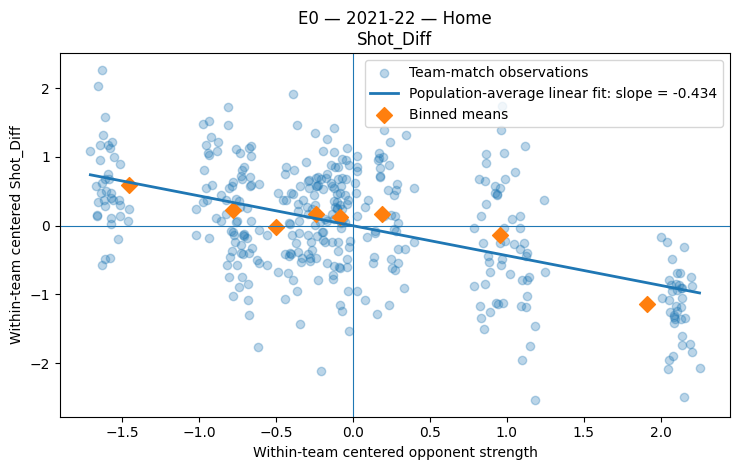

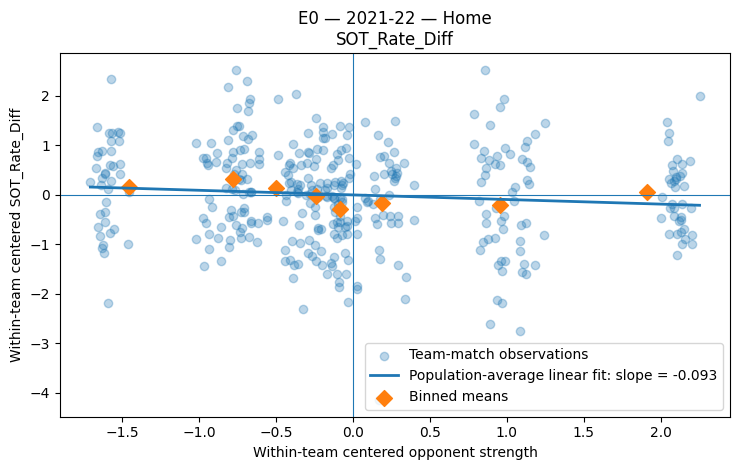

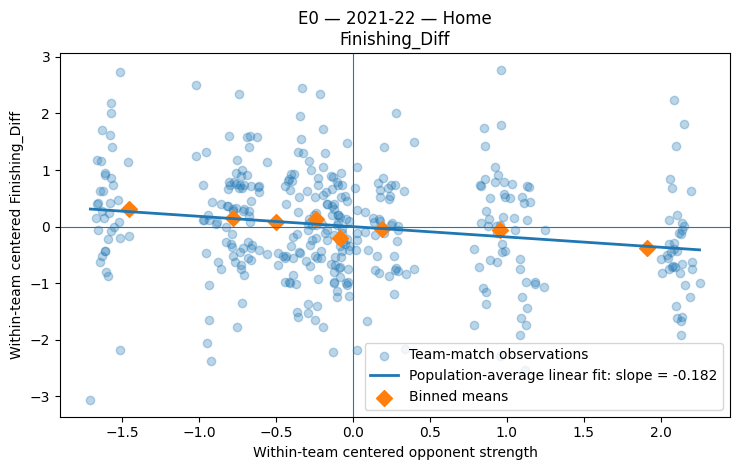

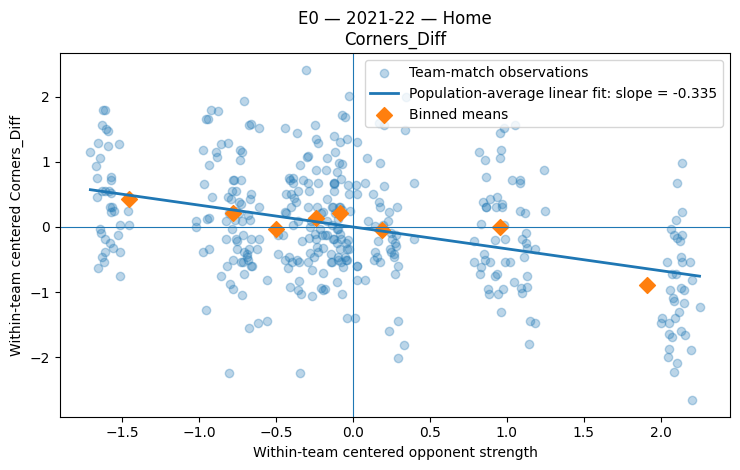

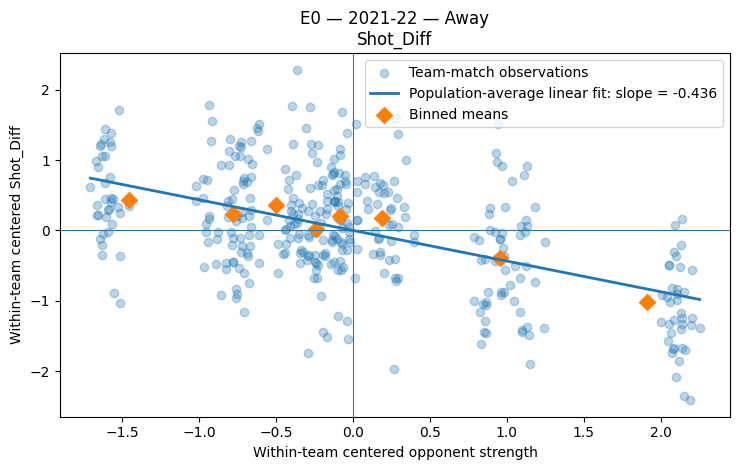

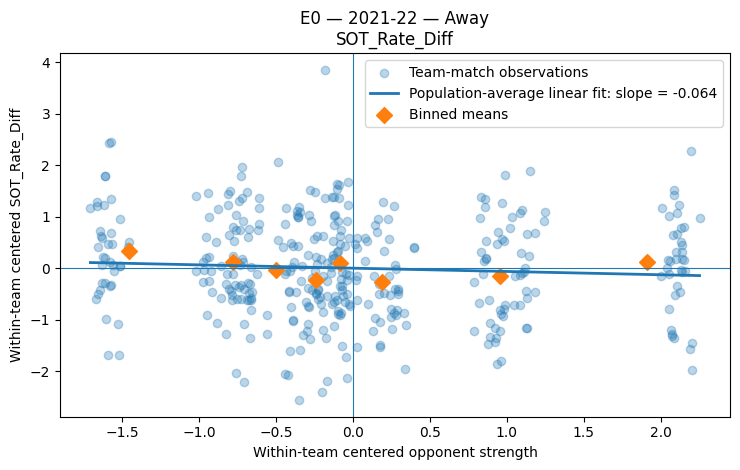

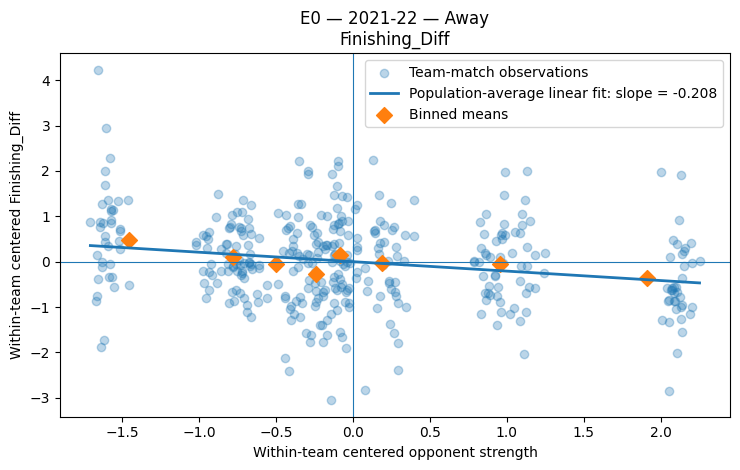

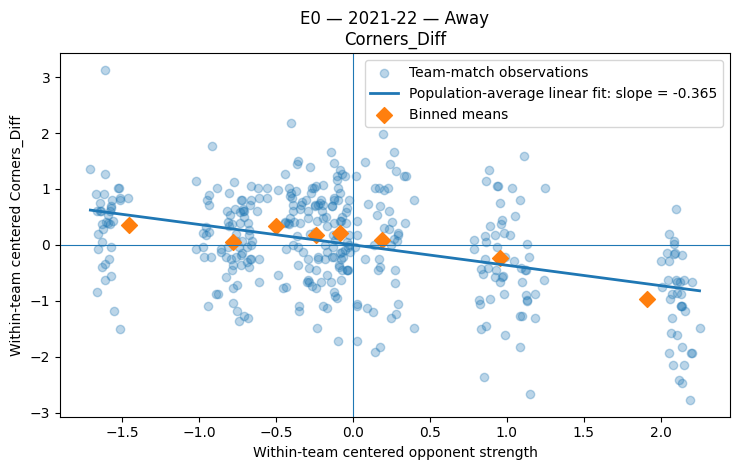

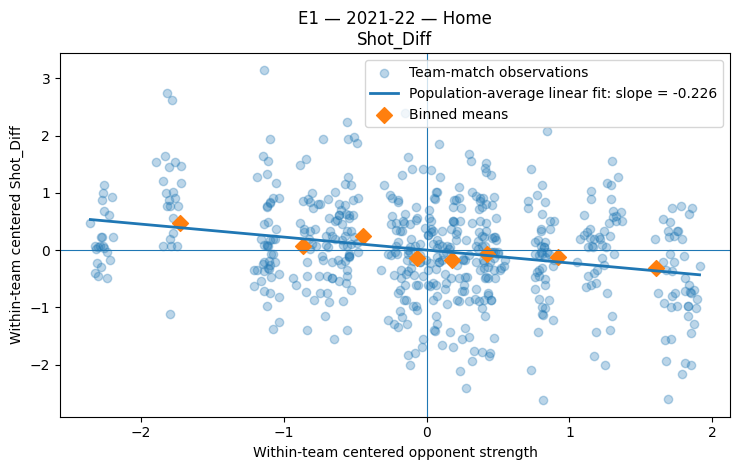

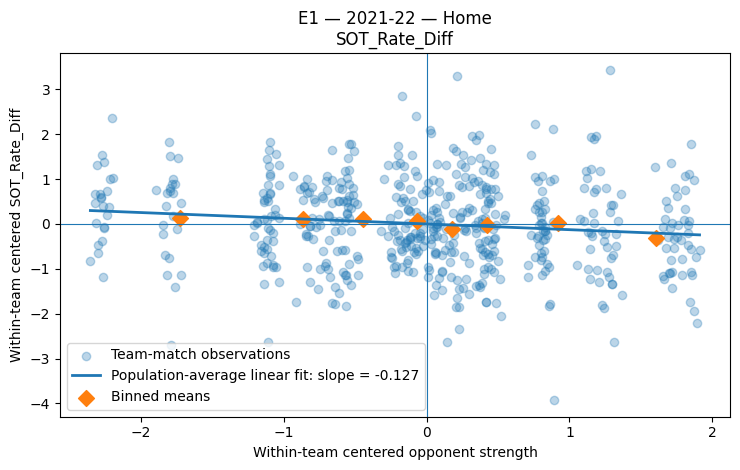

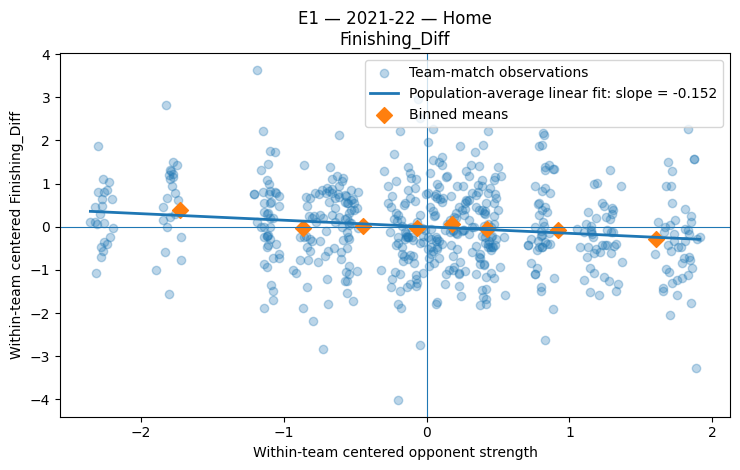

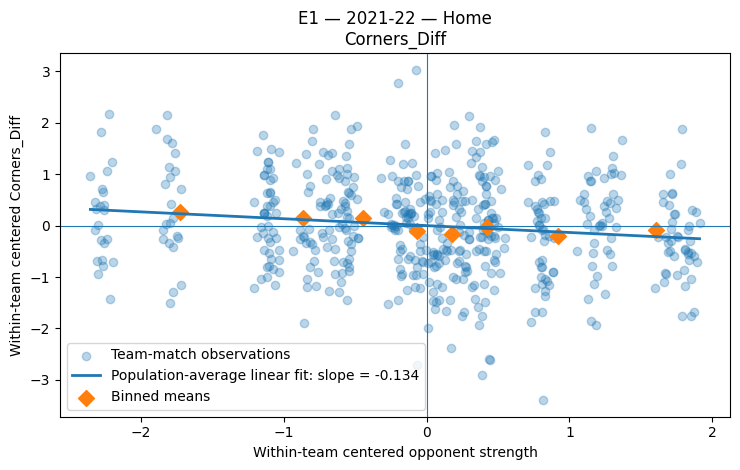

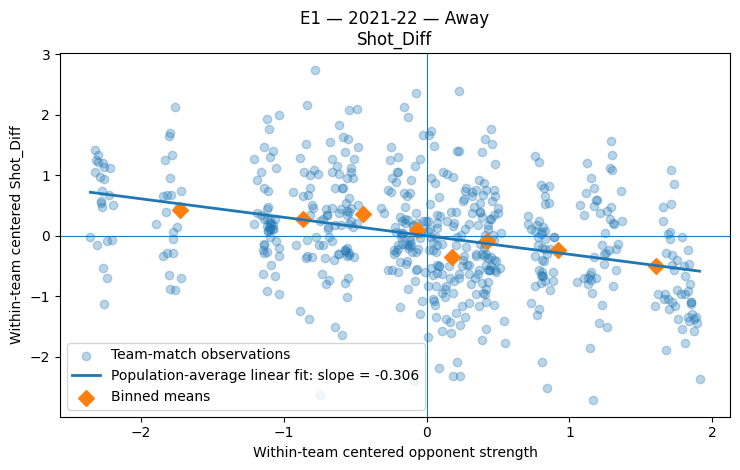

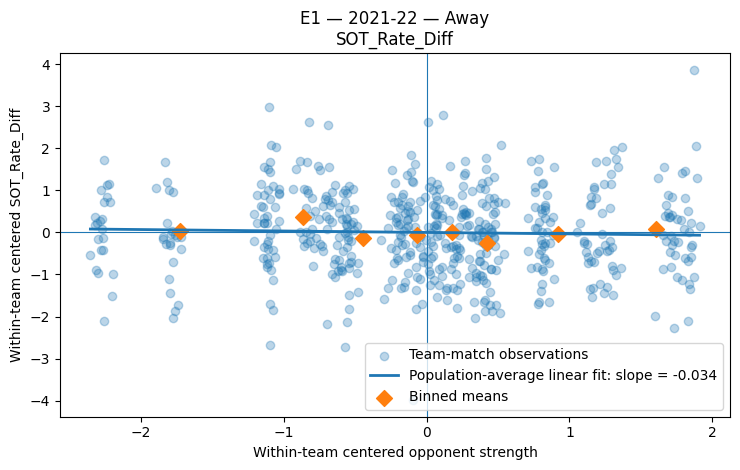

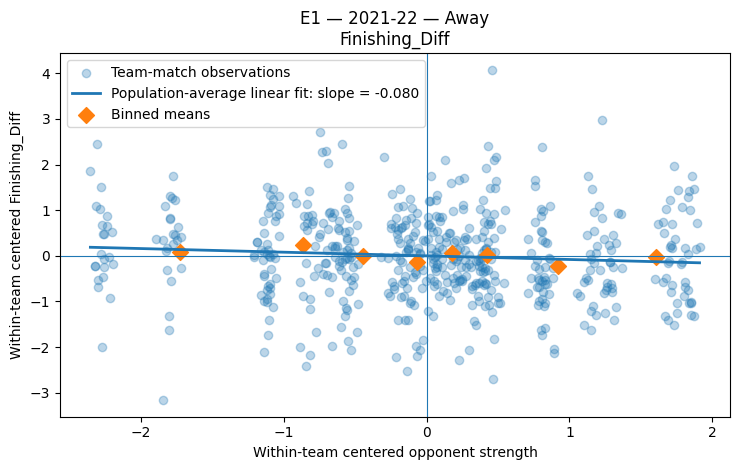

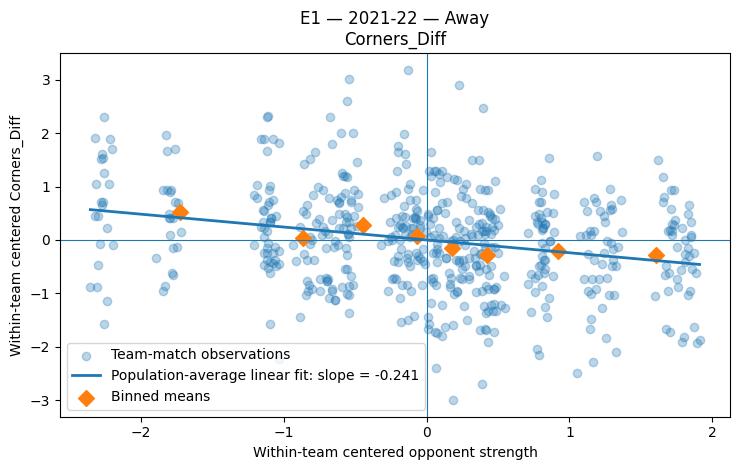

,League,Season,Venue,Feature,N_Observations,N_Teams,League_Mean_Sensitivity,Within_R2
0,E0,2021-22,Home,Shot_Diff,380,20,-0.4341,0.2697
1,E0,2021-22,Home,SOT_Rate_Diff,380,20,-0.0931,0.0092
2,E0,2021-22,Home,Finishing_Diff,380,20,-0.1822,0.0369
3,E0,2021-22,Home,Corners_Diff,380,20,-0.3349,0.1443
4,E0,2021-22,Away,Shot_Diff,380,20,-0.4359,0.2797
5,E0,2021-22,Away,SOT_Rate_Diff,380,20,-0.0640,0.0045
6,E0,2021-22,Away,Finishing_Diff,380,20,-0.2082,0.0467
7,E0,2021-22,Away,Corners_Diff,380,20,-0.3647,0.1683
8,E1,2021-22,Home,Shot_Diff,552,24,-0.2263,0.0681
9,E1,2021-22,Home,SOT_Rate_Diff,552,24,-0.1272,0.0169


In [16]:
# --------------------------------------------------
# 16. Run within-team diagnostics for each league
# --------------------------------------------------

within_linearity_results = []


for league_name in LEAGUES_TO_TEST:

    league_df = opponent_adjustment_data[
        league_name
    ]

    diagnostic_season = (
        TRAIN_SEASON_BY_LEAGUE[
            league_name
        ]
    )

    z_cols = standardized_feature_cols[
        league_name
    ]

    league_summary = (
        plot_league_wide_linearity(
            df=league_df,
            league_name=league_name,
            season=diagnostic_season,
            z_cols=z_cols,
            q_col=Q_COL
        )
    )

    within_linearity_results.append(
        league_summary
    )


within_linearity_summary = pd.concat(
    within_linearity_results,
    ignore_index=True
)

display(
    within_linearity_summary.round(4)
)

All estimated league-mean sensitivities are negative across both leagues,
venues, and performance features. This directionally consistent result
indicates that, after controlling for differences in team baseline levels,
match performance generally declines as opponent strength increases.

The magnitude of the population-average relationship differs substantially
across features. In the Premier League sample, opponent strength has the
strongest association with shot difference. The estimated league-mean
sensitivities are approximately $-0.43$ for both home and away matches, with
within-team $R^2$ values of approximately $0.27$ and $0.28$. Corner difference
also shows a noticeable negative relationship, with within-team $R^2$ values
between approximately $0.14$ and $0.17$.

By contrast, finishing difference has considerably lower explanatory power, and
the relationship for shot-on-target rate difference is particularly weak. This
suggests that these efficiency-based variables are more strongly affected by
short-term match variation than by opponent strength alone.

The Championship results show the same negative population-average direction
but generally smaller sensitivities and lower within-team $R^2$ values.
Opponent strength therefore explains a larger proportion of the selected
performance variation in the Premier League sample than in the Championship
sample during the training season.

These results support the inclusion of an opponent-strength adjustment at the
population level, while also showing that its importance is feature-specific.
A low within-team $R^2$ does not by itself reject the adjustment; it indicates
that opponent strength explains only one component of match-to-match variation.

The estimated slopes should not be interpreted as evidence that all teams
respond identically. Instead, they provide the league-level centers around
which team-specific sensitivities may vary.

### 5.2 Repeated Cross-Validated Linear–Quadratic Comparison

At this diagnostic stage, the coefficients describe the population-average
opponent-strength relationship. The purpose of this comparison is to determine
the functional form of the average relationship, rather than to assume that
every team must have the same sensitivity in the final model.

Team-level variation around the retained population-average structure is
examined separately in Section 5.3.

The quadratic specification is used as a parsimonious nonlinear alternative to
the linear model. It introduces only one additional parameter and can detect
the most common systematic departure from linearity, namely U-shaped or
inverted-U-shaped curvature.

The purpose of this comparison is not to search exhaustively over every
possible nonlinear function. Instead, it evaluates whether a modest increase
in functional complexity produces a meaningful improvement in out-of-sample
performance.

A direct logarithmic transformation is not considered because the standardized
opponent-strength variable contains negative and zero values. Applying a shifted
logarithm would require an arbitrary offset and would weaken the interpretation
of $q=0$ as an average-strength opponent.

The within-team results indicate a generally negative relationship between
opponent strength and match performance. However, they do not by themselves
determine whether this relationship should be represented linearly.

The league-wide linear fixed-effects model is therefore compared with a
quadratic alternative. The linear specification is

$$
z_{i,v,m,k}^{(t)}
=
\alpha_{i,v,k}^{(t)}
+
\mu_{\beta,v,k}^{(t)}q_{j(m)}^{(t)}
+
\varepsilon_{i,v,m,k}^{(t)}.
$$

whereas the quadratic alternative is

$$
z_{i,v,m,k}^{(t)}
=
\alpha_{i,v,k}^{(t)}
+
\mu_{\beta_1,v,k}^{(t)}q_{j(m)}^{(t)}
+
\mu_{\beta_2,v,k}^{(t)}
\left(q_{j(m)}^{(t)}\right)^2
+
\varepsilon_{i,v,m,k}^{(t)}.
$$

Both models include team-specific fixed effects and are estimated separately
for each league, season, venue, and performance feature. The only difference is
the additional quadratic term.

Model performance is evaluated using repeated stratified five-fold
cross-validation. In each repetition, the observations are divided into five
folds while preserving the representation of every team. Four folds are used
for model fitting and the remaining fold is used for validation. The full
five-fold procedure is repeated twenty times.

The linear and quadratic specifications are evaluated using identical folds,
and their out-of-sample performance is compared using cross-validated root mean
squared error:

$$
\operatorname{CV\ RMSE}
=
\sqrt{
\frac{1}{N_{\mathrm{val}}}
\sum_{r=1}^{N_{\mathrm{val}}}
\left(
z_r-\widehat z_r
\right)^2
}.
$$

The quadratic specification is considered meaningfully better only if it
reduces cross-validated RMSE by at least \(5\%\). Smaller differences are not
treated as sufficient evidence for introducing an additional parameter.


In [17]:
# --------------------------------------------------
# 17. Construct fixed-effects design matrices
# --------------------------------------------------

def build_fixed_effect_design(
    sample,
    q_col,
    degree
):
    """
    Construct a regression design matrix containing:

    - team dummy variables;
    - opponent strength q;
    - q squared when degree = 2.
    """

    if degree not in (1, 2):
        raise ValueError(
            "degree must be either 1 or 2."
        )

    team_dummies = pd.get_dummies(
        sample["Team"],
        prefix="Team",
        drop_first=True,
        dtype=float
    )

    design = team_dummies.copy()

    q_values = sample[
        q_col
    ].to_numpy(dtype=float)

    design["q"] = q_values

    if degree == 2:
        design["q_squared"] = (
            q_values ** 2
        )

    return design.to_numpy(
        dtype=float
    )

In [18]:
# --------------------------------------------------
# 18. Compare linear and quadratic models using the
#     same repeated stratified folds
# --------------------------------------------------

def repeated_fixed_effects_comparison(
    sample,
    z_col,
    q_col="Opponent_Strength_q",
    n_splits=5,
    n_repeats=20,
    random_state=42
):
    """
    Compare linear and quadratic fixed-effects models
    using identical repeated stratified folds.
    """

    model_sample = sample[
        ["Team", q_col, z_col]
    ].dropna().copy()

    y = model_sample[
        z_col
    ].to_numpy(dtype=float)

    team_labels = model_sample[
        "Team"
    ].astype(str).to_numpy()

    X_linear = build_fixed_effect_design(
        sample=model_sample,
        q_col=q_col,
        degree=1
    )

    X_quadratic = build_fixed_effect_design(
        sample=model_sample,
        q_col=q_col,
        degree=2
    )

    cross_validator = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )

    linear_squared_errors = []
    quadratic_squared_errors = []

    for train_index, test_index in (
        cross_validator.split(
            X_linear,
            team_labels
        )
    ):

        linear_model = LinearRegression()
        quadratic_model = LinearRegression()

        linear_model.fit(
            X_linear[train_index],
            y[train_index]
        )

        quadratic_model.fit(
            X_quadratic[train_index],
            y[train_index]
        )

        linear_predictions = (
            linear_model.predict(
                X_linear[test_index]
            )
        )

        quadratic_predictions = (
            quadratic_model.predict(
                X_quadratic[test_index]
            )
        )

        linear_squared_errors.extend(
            (
                y[test_index]
                - linear_predictions
            ) ** 2
        )

        quadratic_squared_errors.extend(
            (
                y[test_index]
                - quadratic_predictions
            ) ** 2
        )

    linear_rmse = float(
        np.sqrt(
            np.mean(
                linear_squared_errors
            )
        )
    )

    quadratic_rmse = float(
        np.sqrt(
            np.mean(
                quadratic_squared_errors
            )
        )
    )

    return linear_rmse, quadratic_rmse

In [19]:
# --------------------------------------------------
# 19. Run the league-wide specification comparison
# --------------------------------------------------

def compare_league_wide_specifications(
    df,
    league_name,
    season,
    z_cols,
    q_col="Opponent_Strength_q",
    venues=("Home", "Away"),
    meaningful_reduction=0.05
):
    """
    Compare linear and quadratic fixed-effects models
    for all venue-feature combinations.
    """

    result_rows = []

    for venue in venues:

        venue_sample = df.loc[
            (df["Season"] == season)
            & (df["Venue"] == venue)
        ].copy()

        if venue_sample.empty:
            raise ValueError(
                f"No observations found for "
                f"{league_name}, {season}, {venue}."
            )

        for z_col in z_cols:

            linear_rmse, quadratic_rmse = (
                repeated_fixed_effects_comparison(
                    sample=venue_sample,
                    z_col=z_col,
                    q_col=q_col,
                    n_splits=5,
                    n_repeats=20,
                    random_state=42
                )
            )

            relative_reduction = (
                linear_rmse
                - quadratic_rmse
            ) / linear_rmse

            if (
                relative_reduction
                >= meaningful_reduction
            ):
                indication = (
                    "Inspect quadratic"
                )
            else:
                indication = (
                    "Retain linear"
                )

            result_rows.append({
                "League": league_name,
                "Season": season,
                "Venue": venue,
                "Feature": z_col.replace("z_", ""),
                "N_Observations": len(venue_sample),
                "N_Teams": venue_sample[
                    "Team"
                ].nunique(),
                "Linear_CV_RMSE": linear_rmse,
                "Quadratic_CV_RMSE": quadratic_rmse,
                "Quadratic_RMSE_Reduction": (
                    relative_reduction
                ),
                "Indication": indication
            })

    return pd.DataFrame(
        result_rows
    )

In [20]:
league_specification_results = []


for league_name in LEAGUES_TO_TEST:

    league_df = opponent_adjustment_data[
        league_name
    ]

    diagnostic_season = (
        TRAIN_SEASON_BY_LEAGUE[
            league_name
        ]
    )

    z_cols = standardized_feature_cols[
        league_name
    ]

    league_result = (
        compare_league_wide_specifications(
            df=league_df,
            league_name=league_name,
            season=diagnostic_season,
            z_cols=z_cols,
            q_col=Q_COL,
            meaningful_reduction=0.05
        )
    )

    league_specification_results.append(
        league_result
    )


league_specification_comparison = pd.concat(
    league_specification_results,
    ignore_index=True
)

In [21]:
comparison_display = (
    league_specification_comparison
    .copy()
)

comparison_display[
    "Quadratic_RMSE_Reduction_pct"
] = (
    100
    * comparison_display[
        "Quadratic_RMSE_Reduction"
    ]
)

display_columns = [
    "League",
    "Season",
    "Venue",
    "Feature",
    "N_Observations",
    "N_Teams",
    "Linear_CV_RMSE",
    "Quadratic_CV_RMSE",
    "Quadratic_RMSE_Reduction_pct",
    "Indication"
]

display(
    comparison_display[
        display_columns
    ].round(4)
)

,League,Season,Venue,Feature,N_Observations,N_Teams,Linear_CV_RMSE,Quadratic_CV_RMSE,Quadratic_RMSE_Reduction_pct,Indication
0,E0,2021-22,Home,Shot_Diff,380,20,0.7570,0.7491,1.0440,Retain linear
1,E0,2021-22,Home,SOT_Rate_Diff,380,20,1.0268,1.0242,0.2500,Retain linear
2,E0,2021-22,Home,Finishing_Diff,380,20,0.9908,0.9951,-0.4364,Retain linear
3,E0,2021-22,Home,Corners_Diff,380,20,0.8671,0.8637,0.3933,Retain linear
4,E0,2021-22,Away,Shot_Diff,380,20,0.7431,0.7340,1.2231,Retain linear
5,E0,2021-22,Away,SOT_Rate_Diff,380,20,1.0158,1.0091,0.6679,Retain linear
6,E0,2021-22,Away,Finishing_Diff,380,20,0.9994,1.0018,-0.2357,Retain linear
7,E0,2021-22,Away,Corners_Diff,380,20,0.8623,0.8534,1.0333,Retain linear
8,E1,2021-22,Home,Shot_Diff,552,24,0.8795,0.8810,-0.1644,Retain linear
9,E1,2021-22,Home,SOT_Rate_Diff,552,24,1.0201,1.0222,-0.2051,Retain linear


The quadratic specification does not produce a meaningful improvement in
cross-validated prediction performance for any league, venue, or performance
feature.

Across the sixteen comparisons, the relative change in RMSE ranges from an
increase of approximately $0.44\%$ to a reduction of approximately $1.22\%$.
All observed improvements are substantially below the predefined $5\%$
threshold. In several cases, particularly in the Championship sample, the
quadratic specification performs slightly worse than the linear model.

The small differences between the two specifications indicate that the
additional quadratic term does not capture a stable nonlinear pattern that
generalizes to held-out matches. Its inclusion would increase model complexity
without producing a practically meaningful predictive benefit.

The linear population-average specification is therefore retained:

$$
z_{i,v,m,k}^{(t)}
=
\alpha_{i,v,k}^{(t)}
+
\mu_{\beta,v,k}^{(t)}q_{j(m)}^{(t)}
+
\varepsilon_{i,v,m,k}^{(t)}.
$$

This result concerns the functional form of the population-average relationship.
It does not imply that every team must have the same slope. Instead, it supports
a linear population-level structure around which team-specific linear
sensitivities may vary.

The result should also not be interpreted as proof that the linear model is
optimal among every possible nonlinear specification. It shows that the tested
quadratic extension does not provide a practically meaningful improvement.
Given the absence of clear systematic curvature, the limited predictive gain
from additional complexity, and the need to preserve an interpretable
opponent-sensitivity coefficient, the linear form is retained as the most
parsimonious specification examined.

### 5.3 Testing Team-Level Sensitivity Heterogeneity

Although Sections 5.1 and 5.2 support a generally negative and approximately
linear population-average opponent-strength relationship, they do not establish
that every team responds identically.

Different tactical structures, playing styles, and risk preferences may cause
teams to react differently when opponent strength changes. A strong
possession-based team may preserve its attacking output against strong
opponents, whereas another team may experience a much sharper decline.

However, estimating a completely independent slope from only 19 Premier League
home or away matches, or 23 Championship matches, may produce unstable and
extreme estimates. The analysis therefore considers a partially pooled
hierarchical random-slope model.

The common-slope baseline is

$$
z_{i,v,m,k}^{(t)}
=
\alpha_{i,v,k}^{(t)}
+
\mu_{\beta,v,k}^{(t)}q_{j(m)}^{(t)}
+
\varepsilon_{i,v,m,k}^{(t)}.
$$

The hierarchical alternative is

$$
z_{i,v,m,k}^{(t)}
=
\alpha_{i,v,k}^{(t)}
+
\beta_{i,v,k}^{(t)}q_{j(m)}^{(t)}
+
\varepsilon_{i,v,m,k}^{(t)},
$$

where the team-specific sensitivities satisfy

$$
\beta_{i,v,k}^{(t)}
=
\mu_{\beta,v,k}^{(t)}
+
u_{i,v,k}^{(t)},
$$

and

$$
u_{i,v,k}^{(t)}
\sim
\mathcal N
\left(
0,
\tau_{\beta,v,k}^{2}
\right).
$$

Equivalently,

$$
\beta_{i,v,k}^{(t)}
\sim
\mathcal N
\left(
\mu_{\beta,v,k}^{(t)},
\tau_{\beta,v,k}^{2}
\right).
$$

Here:

- $\mu_{\beta,v,k}^{(t)}$ is the league-mean opponent-strength sensitivity;
- $\beta_{i,v,k}^{(t)}$ is team $i$'s partially pooled sensitivity;
- $u_{i,v,k}^{(t)}$ is the team's deviation from the league mean;
- $\tau_{\beta,v,k}$ measures sensitivity heterogeneity across teams.

When $\tau_{\beta,v,k}$ is close to zero, team sensitivities are concentrated
around the league mean and the common-slope model may be sufficient.

When $\tau_{\beta,v,k}$ is meaningfully greater than zero, teams exhibit
different responses to opponent strength, supporting the use of partially
pooled team-specific slopes.

The common-slope and random-slope specifications should be compared using the
same held-out match observations. The hierarchical model will be retained only
when it produces a meaningful improvement in out-of-sample performance and the
estimated random-slope variation does not collapse toward zero.

The hierarchical model is estimated as a linear mixed-effects model. The
league-mean sensitivity, team baseline effects, between-team random-slope
variance, and match-level residual variance are estimated within a common
likelihood framework.

The team-specific deviations are not randomly generated after fitting the
league mean. Instead, they are predicted conditionally from each team's match
observations and the estimated variance structure. Teams whose individual
slope evidence is weak or noisy are shrunk more strongly toward the league
mean, whereas teams with more consistent evidence are allowed to deviate
further.

The final partially pooled sensitivity is

$$
\widehat\beta_{i,v,k}^{(t)}
=
\widehat\mu_{\beta,v,k}^{(t)}
+
\widehat u_{i,v,k}^{(t)}.
$$

The implementation uses maximum-likelihood estimation through a mixed-effects
model. The fitted team deviations are empirical best linear unbiased
predictions rather than independently estimated ordinary least-squares slopes.

In [22]:
# --------------------------------------------------
# 20. Prepare the random-slope heterogeneity analysis
# --------------------------------------------------

import warnings
import statsmodels.formula.api as smf

from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning
)


def prepare_heterogeneity_sample(
    df,
    season,
    venue,
    z_col,
    q_col="Opponent_Strength_q"
):
    """
    Select one league-season-venue-feature sample for
    the team-sensitivity heterogeneity test.
    """

    sample = df.loc[
        (df["Season"] == season)
        & (df["Venue"] == venue),
        [
            "Team",
            q_col,
            z_col
        ]
    ].dropna().copy()

    if sample.empty:
        raise ValueError(
            f"No observations found for "
            f"{season}, {venue}, {z_col}."
        )

    sample["Team"] = (
        sample["Team"]
        .astype(str)
    )

    team_counts = (
        sample.groupby("Team")
        .size()
    )

    if team_counts.min() < 2:
        invalid_teams = (
            team_counts[
                team_counts < 2
            ]
            .index
            .tolist()
        )

        raise ValueError(
            "At least two observations per team are "
            f"required. Invalid teams: {invalid_teams}"
        )

    return sample.reset_index(
        drop=True
    )

In [23]:
# --------------------------------------------------
# 21. Fit the partially pooled random-slope model
# --------------------------------------------------

def fit_random_slope_model(
    sample,
    z_col,
    q_col="Opponent_Strength_q",
    maxiter=500
):
    """
    Fit:

        z_im = alpha_i + (mu_beta + u_i) * q_m + epsilon_im

    Team intercepts are treated as fixed effects.
    Team slope deviations are treated as random effects.
    """

    formula = (
        f"{z_col} "
        f"~ C(Team) + {q_col}"
    )

    # Random slope only:
    # no random intercept because team intercepts are
    # already represented by C(Team).
    random_formula = (
        f"0 + {q_col}"
    )

    fitting_errors = []

    # Multiple optimizers are attempted because random-slope
    # models may occasionally have convergence difficulties.
    for method in (
        "bfgs",
        "cg",
        "powell"
    ):

        try:

            model = smf.mixedlm(
                formula=formula,
                data=sample,
                groups=sample["Team"],
                re_formula=random_formula
            )

            with warnings.catch_warnings():

                warnings.simplefilter(
                    "ignore",
                    ConvergenceWarning
                )

                warnings.simplefilter(
                    "ignore",
                    RuntimeWarning
                )

                result = model.fit(
                    reml=False,
                    method=method,
                    maxiter=maxiter,
                    disp=False
                )

            random_slope_variance = float(
                result.cov_re.iloc[
                    0,
                    0
                ]
            )

            valid_result = (
                bool(result.converged)
                and np.isfinite(result.llf)
                and np.isfinite(
                    random_slope_variance
                )
                and np.all(
                    np.isfinite(
                        result.fe_params
                        .to_numpy(
                            dtype=float
                        )
                    )
                )
            )

            if valid_result:
                return result, method

            fitting_errors.append(
                f"{method}: invalid or "
                "non-converged result"
            )

        except Exception as error:

            fitting_errors.append(
                f"{method}: "
                f"{type(error).__name__}: "
                f"{error}"
            )

    raise RuntimeError(
        "The random-slope model failed. "
        + " | ".join(
            fitting_errors
        )
    )

In [24]:
# --------------------------------------------------
# 22. Estimate league mean and team sensitivities
# --------------------------------------------------

def estimate_team_sensitivities(
    sample,
    league_name,
    season,
    venue,
    z_col,
    q_col="Opponent_Strength_q"
):
    """
    Estimate:

    1. common-slope OLS sensitivity;
    2. hierarchical league-mean sensitivity;
    3. random-slope standard deviation;
    4. partially pooled team sensitivities.
    """

    common_formula = (
        f"{z_col} "
        f"~ C(Team) + {q_col}"
    )

    # Complete-pooling slope baseline
    common_model = smf.ols(
        formula=common_formula,
        data=sample
    ).fit()

    # Partially pooled random-slope model
    mixed_result, optimizer = (
        fit_random_slope_model(
            sample=sample,
            z_col=z_col,
            q_col=q_col
        )
    )

    # Population-average sensitivity
    mu_beta = float(
        mixed_result.fe_params[
            q_col
        ]
    )

    # Between-team slope standard deviation
    tau_beta = float(
        np.sqrt(
            max(
                mixed_result.cov_re.iloc[
                    0,
                    0
                ],
                0.0
            )
        )
    )

    residual_sd = float(
        np.sqrt(
            mixed_result.scale
        )
    )

    # Extract partially pooled team deviations
    try:
        random_effects = (
            mixed_result.random_effects
        )
    except ValueError:
        # A singular covariance means tau_beta is
        # effectively zero.
        random_effects = {}

    team_rows = []

    for team in sorted(
        sample["Team"].unique()
    ):

        if team in random_effects:

            team_deviation = float(
                random_effects[
                    team
                ].iloc[0]
            )

        else:

            team_deviation = 0.0

        team_beta = (
            mu_beta
            + team_deviation
        )

        team_rows.append({
            "League": league_name,
            "Season": season,
            "Venue": venue,
            "Feature": z_col.replace(
                "z_",
                ""
            ),
            "Team": team,
            "League_Mean_Sensitivity": (
                mu_beta
            ),
            "Team_Slope_Deviation": (
                team_deviation
            ),
            "Team_Sensitivity_Beta": (
                team_beta
            )
        })

    model_summary = {
        "League": league_name,
        "Season": season,
        "Venue": venue,
        "Feature": z_col.replace(
            "z_",
            ""
        ),
        "N_Observations": len(sample),
        "N_Teams": (
            sample["Team"].nunique()
        ),
        "Common_OLS_Sensitivity": float(
            common_model.params[
                q_col
            ]
        ),
        "Hierarchical_Mean_Sensitivity": (
            mu_beta
        ),
        "Random_Slope_SD": tau_beta,
        "Residual_SD": residual_sd,
        "MixedLM_Converged": bool(
            mixed_result.converged
        ),
        "Optimizer": optimizer
    }

    return (
        model_summary,
        pd.DataFrame(
            team_rows
        )
    )

In [25]:
# --------------------------------------------------
# 23. Predict with the fitted random-slope model
# --------------------------------------------------

def predict_random_slope_model(
    result,
    test_sample,
    q_col="Opponent_Strength_q"
):
    """
    statsmodels predict() returns the fixed-effects
    prediction. The team random-slope contribution
    is added manually.
    """

    fixed_prediction = (
        result.predict(
            test_sample
        )
        .to_numpy(
            dtype=float
        )
    )

    try:
        random_effects = (
            result.random_effects
        )
    except ValueError:
        random_effects = {}

    team_deviations = np.array([
        (
            float(
                random_effects[
                    team
                ].iloc[0]
            )
            if team in random_effects
            else 0.0
        )
        for team in test_sample[
            "Team"
        ]
    ])

    q_values = (
        test_sample[
            q_col
        ]
        .to_numpy(
            dtype=float
        )
    )

    return (
        fixed_prediction
        + team_deviations
        * q_values
    )

In [26]:
# --------------------------------------------------
# 24. Repeated CV comparison:
#     common slope vs hierarchical slopes
# --------------------------------------------------

def repeated_sensitivity_comparison(
    sample,
    z_col,
    q_col="Opponent_Strength_q",
    n_splits=5,
    n_repeats=5,
    random_state=42
):
    """
    Compare:

    1. team fixed intercepts + one common slope;
    2. team fixed intercepts + partially pooled slopes.

    Identical folds are used for both models.
    """

    formula = (
        f"{z_col} "
        f"~ C(Team) + {q_col}"
    )

    team_labels = (
        sample["Team"]
        .to_numpy(
            dtype=str
        )
    )

    cross_validator = (
        RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=random_state
        )
    )

    common_squared_errors = []
    hierarchical_squared_errors = []

    successful_folds = 0
    failed_folds = 0

    split_input = np.zeros(
        len(sample)
    )

    for train_index, test_index in (
        cross_validator.split(
            split_input,
            team_labels
        )
    ):

        train_sample = (
            sample.iloc[
                train_index
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )

        test_sample = (
            sample.iloc[
                test_index
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )

        y_test = (
            test_sample[
                z_col
            ]
            .to_numpy(
                dtype=float
            )
        )

        # ------------------------------
        # Common-slope model
        # ------------------------------

        common_model = smf.ols(
            formula=formula,
            data=train_sample
        ).fit()

        common_prediction = (
            common_model.predict(
                test_sample
            )
            .to_numpy(
                dtype=float
            )
        )

        # ------------------------------
        # Hierarchical random-slope model
        # ------------------------------

        try:

            mixed_result, _ = (
                fit_random_slope_model(
                    sample=train_sample,
                    z_col=z_col,
                    q_col=q_col
                )
            )

            hierarchical_prediction = (
                predict_random_slope_model(
                    result=mixed_result,
                    test_sample=test_sample,
                    q_col=q_col
                )
            )

        except RuntimeError:

            failed_folds += 1
            continue

        # Only use folds in which both models
        # were successfully evaluated.
        common_squared_errors.extend(
            (
                y_test
                - common_prediction
            ) ** 2
        )

        hierarchical_squared_errors.extend(
            (
                y_test
                - hierarchical_prediction
            ) ** 2
        )

        successful_folds += 1

    if successful_folds == 0:
        raise RuntimeError(
            "Every hierarchical CV fit failed."
        )

    common_rmse = float(
        np.sqrt(
            np.mean(
                common_squared_errors
            )
        )
    )

    hierarchical_rmse = float(
        np.sqrt(
            np.mean(
                hierarchical_squared_errors
            )
        )
    )

    relative_reduction = (
        common_rmse
        - hierarchical_rmse
    ) / common_rmse

    return {
        "Common_Slope_CV_RMSE": (
            common_rmse
        ),
        "Hierarchical_CV_RMSE": (
            hierarchical_rmse
        ),
        "Hierarchical_RMSE_Reduction": (
            relative_reduction
        ),
        "Successful_CV_Folds": (
            successful_folds
        ),
        "Failed_CV_Folds": (
            failed_folds
        )
    }

In [27]:
# --------------------------------------------------
# 25. Run the heterogeneity analysis
# --------------------------------------------------

N_REPEATS_HETEROGENEITY = 20

MEANINGFUL_RMSE_REDUCTION = 0.05


heterogeneity_rows = []

team_sensitivity_tables = []


for league_name in LEAGUES_TO_TEST:

    league_df = opponent_adjustment_data[
        league_name
    ]

    diagnostic_season = (
        TRAIN_SEASON_BY_LEAGUE[
            league_name
        ]
    )

    z_cols = standardized_feature_cols[
        league_name
    ]

    for venue in (
        "Home",
        "Away"
    ):

        for z_col in z_cols:

            sample = (
                prepare_heterogeneity_sample(
                    df=league_df,
                    season=diagnostic_season,
                    venue=venue,
                    z_col=z_col,
                    q_col=Q_COL
                )
            )

            (
                model_summary,
                team_sensitivity_table
            ) = estimate_team_sensitivities(
                sample=sample,
                league_name=league_name,
                season=diagnostic_season,
                venue=venue,
                z_col=z_col,
                q_col=Q_COL
            )

            cv_summary = (
                repeated_sensitivity_comparison(
                    sample=sample,
                    z_col=z_col,
                    q_col=Q_COL,
                    n_splits=5,
                    n_repeats=(
                        N_REPEATS_HETEROGENEITY
                    ),
                    random_state=42
                )
            )

            result_row = {
                **model_summary,
                **cv_summary
            }

            rmse_reduction = (
                result_row[
                    "Hierarchical_RMSE_Reduction"
                ]
            )

            random_slope_sd = (
                result_row[
                    "Random_Slope_SD"
                ]
            )

            if (
                random_slope_sd < 1e-4
                or rmse_reduction <= 0
            ):

                indication = (
                    "Retain common slope"
                )

            elif (
                rmse_reduction
                >= MEANINGFUL_RMSE_REDUCTION
            ):

                indication = (
                    "Retain hierarchical slopes"
                )

            else:

                indication = (
                    "Weak heterogeneity evidence"
                )

            result_row[
                "Indication"
            ] = indication

            heterogeneity_rows.append(
                result_row
            )

            team_sensitivity_tables.append(
                team_sensitivity_table
            )


sensitivity_heterogeneity_comparison = (
    pd.DataFrame(
        heterogeneity_rows
    )
)

team_sensitivity_diagnostics = (
    pd.concat(
        team_sensitivity_tables,
        ignore_index=True
    )
)

c:\Users\TK\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\TK\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\TK\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\TK\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\TK\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\TK\AppData\Local\Programs\

In [28]:
heterogeneity_display = (
    sensitivity_heterogeneity_comparison
    .copy()
)

heterogeneity_display[
    "Hierarchical_RMSE_Reduction_pct"
] = (
    100
    * heterogeneity_display[
        "Hierarchical_RMSE_Reduction"
    ]
)

display_columns = [
    "League",
    "Season",
    "Venue",
    "Feature",
    "N_Observations",
    "N_Teams",
    "Common_OLS_Sensitivity",
    "Hierarchical_Mean_Sensitivity",
    "Random_Slope_SD",
    "Common_Slope_CV_RMSE",
    "Hierarchical_CV_RMSE",
    "Hierarchical_RMSE_Reduction_pct",
    "Successful_CV_Folds",
    "Failed_CV_Folds",
    "Indication"
]

display(
    heterogeneity_display[
        display_columns
    ].round(4)
)

,League,Season,Venue,Feature,N_Observations,N_Teams,Common_OLS_Sensitivity,Hierarchical_Mean_Sensitivity,Random_Slope_SD,Common_Slope_CV_RMSE,Hierarchical_CV_RMSE,Hierarchical_RMSE_Reduction_pct,Successful_CV_Folds,Failed_CV_Folds,Indication
0,E0,2021-22,Home,Shot_Diff,380,20,-0.4341,-0.4330,0.0991,0.7570,0.7569,0.0013,100,0,Weak heterogeneity evidence
1,E0,2021-22,Home,SOT_Rate_Diff,380,20,-0.0931,-0.0931,0.0002,1.0268,1.0268,-0.0043,100,0,Retain common slope
2,E0,2021-22,Home,Finishing_Diff,380,20,-0.1822,-0.1830,0.1303,0.9908,0.9946,-0.3812,100,0,Retain common slope
3,E0,2021-22,Home,Corners_Diff,380,20,-0.3349,-0.3339,0.0841,0.8671,0.8692,-0.2471,100,0,Retain common slope
4,E0,2021-22,Away,Shot_Diff,380,20,-0.4359,-0.4359,0.0000,0.7431,0.7438,-0.0876,100,0,Retain common slope
5,E0,2021-22,Away,SOT_Rate_Diff,380,20,-0.0640,-0.0642,0.0739,1.0158,1.0191,-0.3158,100,0,Retain common slope
6,E0,2021-22,Away,Finishing_Diff,380,20,-0.2082,-0.2082,0.0000,0.9994,1.0013,-0.1836,100,0,Retain common slope
7,E0,2021-22,Away,Corners_Diff,380,20,-0.3647,-0.3647,0.0002,0.8623,0.8637,-0.1570,100,0,Retain common slope
8,E1,2021-22,Home,Shot_Diff,552,24,-0.2263,-0.2260,0.0682,0.8795,0.8808,-0.1423,100,0,Retain common slope
9,E1,2021-22,Home,SOT_Rate_Diff,552,24,-0.1272,-0.1272,0.0384,1.0201,1.0218,-0.1701,100,0,Retain common slope


#### Interpretation of the Model-Comparison Columns

The columns beginning with `Common_OLS_Sensitivity` compare the common-slope
baseline with the hierarchical random-slope specification.

- **`Common_OLS_Sensitivity`**

  This is the estimated opponent-strength sensitivity from the common-slope
  fixed-effects model:

  $$
  z_{i,m}
  =
  \alpha_i
  +
  \beta_{\mathrm{common}}q_{i,m}
  +
  \varepsilon_{i,m}.
  $$

  All teams have separate baseline intercepts, but they share one opponent-
  strength slope.

  Because both the performance feature and opponent strength are standardized,
  a value of $-0.43$ means that a one-standard-deviation increase in opponent
  strength is associated with an average decrease of approximately $0.43$
  standard deviations in the performance feature.

  More negative values indicate a stronger decline in performance against
  stronger opponents. Values closer to zero indicate a weaker opponent-strength
  relationship.

- **`Hierarchical_Mean_Sensitivity`**

  This is the estimated league-mean sensitivity from the hierarchical
  random-slope model:

  $$
  \widehat{\mu}_\beta.
  $$

  It is the center of the team-specific sensitivity distribution:

  $$
  \beta_i
  =
  \mu_\beta
  +
  u_i.
  $$

  Its interpretation is similar to `Common_OLS_Sensitivity`, except that it is
  estimated while allowing individual teams to have random slope deviations.

  Close agreement between `Common_OLS_Sensitivity` and
  `Hierarchical_Mean_Sensitivity` indicates that the estimated population-level
  opponent effect is stable across the two model structures.

- **`Random_Slope_SD`**

  This is the estimated standard deviation of the team-specific random slopes:

  $$
  \widehat{\tau}_\beta.
  $$

  It measures how much team sensitivities vary around the league mean.

  - A value close to zero indicates that the data provide little evidence of
    meaningful sensitivity differences across teams.
  - A larger value indicates greater estimated between-team heterogeneity.
  - A nonzero value alone does not justify retaining the hierarchical model;
    the additional variation should also improve out-of-sample prediction.

- **`Common_Slope_CV_RMSE`**

  This is the repeated cross-validated root mean squared error of the
  common-slope model.

  $$
  RMSE_{\mathrm{common}}
  =
  \sqrt{
  \frac{1}{N_{\mathrm{test}}}
  \sum
  \left(
  z_m-\widehat z_m^{\mathrm{common}}
  \right)^2
  }.
  $$

  The model is fitted using the training portion of each fold and evaluated on
  temporarily held-out match observations.

  Lower values indicate better out-of-sample prediction. Since the dependent
  features are standardized, the RMSE is measured in standard-deviation units.

- **`Hierarchical_CV_RMSE`**

  This is the repeated cross-validated RMSE of the hierarchical random-slope
  model.

  $$
  RMSE_{\mathrm{hierarchical}}
  =
  \sqrt{
  \frac{1}{N_{\mathrm{test}}}
  \sum
  \left(
  z_m-\widehat z_m^{\mathrm{hierarchical}}
  \right)^2
  }.
  $$

  It is calculated using the same training-test folds as the common-slope RMSE,
  allowing a direct comparison between the two models.

  A lower hierarchical RMSE would indicate that team-specific random slopes
  improve prediction on held-out matches.

- **`Hierarchical_RMSE_Reduction_pct`**

  This reports the percentage reduction in cross-validated RMSE achieved by the
  hierarchical model:

  $$
  100
  \times
  \frac{
  RMSE_{\mathrm{common}}
  -
  RMSE_{\mathrm{hierarchical}}
  }{
  RMSE_{\mathrm{common}}
  }.
  $$

  - A positive value means that the hierarchical model performs better.
  - A negative value means that the hierarchical model performs worse.
  - A value close to zero means that the two models have nearly identical
    predictive performance.

  For example, a value of $0.0013$ in this percentage column represents only
  a $0.0013\%$ RMSE reduction, which is practically negligible.

  A predefined $5\%$ improvement threshold is used to identify a practically
  meaningful predictive gain.

- **`Successful_CV_Folds`**

  This is the number of cross-validation folds in which both models were fitted
  and evaluated successfully.

  With five folds repeated twenty times, the maximum is

  $$
  5\times20=100.
  $$

  A value of 100 indicates that all repeated cross-validation fits were
  completed successfully.

- **`Failed_CV_Folds`**

  This is the number of folds in which the hierarchical model could not be
  evaluated because of convergence or fitting failure.

  A value of zero indicates that the model-comparison result is not affected by
  failed MixedLM fits.

- **`Indication`**

  This is the model-selection label generated from the estimated random-slope
  variation and cross-validated RMSE comparison.

  - **`Retain common slope`** indicates that the hierarchical model does not
    improve predictive performance, or that the estimated random-slope
    variation is effectively zero.
  - **`Weak heterogeneity evidence`** indicates that some between-team slope
    variation is estimated and the hierarchical RMSE is slightly lower, but the
    improvement remains below the predefined $5\%$ practical threshold.
  - **`Retain hierarchical slopes`** would indicate that random-slope variation
    is present and that the hierarchical model reduces cross-validated RMSE by
    at least $5\%$.

In [29]:
display(
    team_sensitivity_diagnostics
    .sort_values(
        [
            "League",
            "Season",
            "Venue",
            "Feature",
            "Team_Sensitivity_Beta"
        ]
    )
    .round(4)
)

,League,Season,Venue,Feature,Team,League_Mean_Sensitivity,Team_Slope_Deviation,Team_Sensitivity_Beta
147,E0,2021-22,Away,Corners_Diff,Everton,-0.3647,-0.0000,-0.3647
150,E0,2021-22,Away,Corners_Diff,Liverpool,-0.3647,-0.0000,-0.3647
140,E0,2021-22,Away,Corners_Diff,Arsenal,-0.3647,-0.0000,-0.3647
156,E0,2021-22,Away,Corners_Diff,Tottenham,-0.3647,-0.0000,-0.3647
152,E0,2021-22,Away,Corners_Diff,Man United,-0.3647,-0.0000,-0.3647
...,...,...,...,...,...,...,...,...
172,E1,2021-22,Home,Shot_Diff,Luton,-0.2260,0.0189,-0.2071
175,E1,2021-22,Home,Shot_Diff,Nott'm Forest,-0.2260,0.0218,-0.2042
161,E1,2021-22,Home,Shot_Diff,Birmingham,-0.2260,0.0240,-0.2020
169,E1,2021-22,Home,Shot_Diff,Fulham,-0.2260,0.0272,-0.1988


#### Interpretation of the Team-Specific Sensitivity Columns

The second table reports the partially pooled sensitivity estimates produced by
the hierarchical random-slope model.

- **`League_Mean_Sensitivity`**

  This is the league-level mean opponent-strength sensitivity:

  $$
  \widehat{\mu}_\beta.
  $$

  It is the same population-level quantity reported as
  `Hierarchical_Mean_Sensitivity` in the model-comparison table.

  For example, a value of \(-0.4330\) means that, at the league level, a
  one-standard-deviation increase in opponent strength is associated with an
  average decrease of approximately \(0.4330\) standard deviations in the
  corresponding performance feature.

- **`Team_Slope_Deviation`**

  This is the estimated team-specific random-slope deviation:

  $$
  \widehat u_i.
  $$

  It measures how far team \(i\)'s sensitivity is estimated to lie from the
  league mean.

  When the league-mean sensitivity is negative:

  - A positive deviation makes the team sensitivity less negative, indicating
    that the team's performance declines less strongly than the league average
    against stronger opponents.
  - A negative deviation makes the team sensitivity more negative, indicating
    a stronger decline than the league average.
  - A deviation close to zero indicates that the team's match data do not
    provide sufficient evidence for a meaningful departure from the league
    mean.

  The deviation is a partially pooled shrinkage estimate rather than an
  independently estimated ordinary least-squares slope.

- **`Team_Sensitivity_Beta`**

  This is the final partially pooled team-specific opponent sensitivity:

  $$
  \widehat\beta_i
  =
  \widehat\mu_\beta
  +
  \widehat u_i.
  $$

  For example, if

  $$
  \widehat\mu_\beta=-0.4330
  $$

  and

  $$
  \widehat u_i=0.0707,
  $$

  then

  $$
  \widehat\beta_i
  =
  -0.4330+0.0707
  =
  -0.3623.
  $$

  This means that a one-standard-deviation increase in opponent strength is
  associated with an estimated decrease of approximately \(0.3623\) standard
  deviations in that team's performance feature.

  These team-specific estimates are retained as diagnostic outputs. When the
  hierarchical model does not meaningfully improve cross-validated prediction,
  the subsequent adjustment model uses the common slope rather than these
  team-specific sensitivities.

In [30]:
man_city_sensitivity = (
    team_sensitivity_diagnostics.loc[
        team_sensitivity_diagnostics[
            "Team"
        ] == "Man City"
    ]
    .sort_values(
        [
            "Season",
            "Venue",
            "Feature"
        ]
    )
)

display(
    man_city_sensitivity.round(4)
)

,League,Season,Venue,Feature,Team,League_Mean_Sensitivity,Team_Slope_Deviation,Team_Sensitivity_Beta
151,E0,2021-22,Away,Corners_Diff,Man City,-0.3647,0.0000,-0.3647
131,E0,2021-22,Away,Finishing_Diff,Man City,-0.2082,0.0000,-0.2082
111,E0,2021-22,Away,SOT_Rate_Diff,Man City,-0.0642,-0.0214,-0.0856
91,E0,2021-22,Away,Shot_Diff,Man City,-0.4359,0.0000,-0.4359
71,E0,2021-22,Home,Corners_Diff,Man City,-0.3339,0.0682,-0.2657
51,E0,2021-22,Home,Finishing_Diff,Man City,-0.1830,-0.0555,-0.2384
31,E0,2021-22,Home,SOT_Rate_Diff,Man City,-0.0931,-0.0000,-0.0931
11,E0,2021-22,Home,Shot_Diff,Man City,-0.4330,0.0707,-0.3622


#### Results: Team-Level Sensitivity Heterogeneity

The hierarchical random-slope analysis was used to determine whether teams
require distinct opponent-strength sensitivities or whether a common
league-level sensitivity provides a more stable specification.

The estimated hierarchical mean sensitivities are nearly identical to the
corresponding common-slope OLS estimates across all leagues, venues, and
performance features. This agreement indicates that the population-average
opponent-strength effects are stable and are not materially altered by the
introduction of team-level random slopes.

Some specifications produce nonzero estimates of the between-team random-slope
standard deviation. The largest estimated heterogeneity appears in the Premier
League home finishing-difference model and the Premier League home shot-
difference model. However, nonzero random-slope variation alone is insufficient
to justify the more complex hierarchical specification. The team-level
variation must also produce a meaningful improvement in out-of-sample
prediction.

The repeated cross-validation results provide no practically meaningful
predictive advantage for the hierarchical model. Only the Premier League home
shot-difference specification produces a positive RMSE reduction, and the
improvement is approximately $0.0013\%$, which is effectively zero and far
below the predefined $5\%$ threshold. In all remaining specifications, the
hierarchical model either performs approximately identically to or slightly
worse than the common-slope model.

All one hundred cross-validation fits are completed successfully for every
specification, with no failed folds. Therefore, the absence of predictive
improvement cannot be attributed to numerical convergence failures.

These results indicate that the current season-level data do not provide
sufficient evidence to retain team-specific opponent-strength slopes. Although
limited team-level heterogeneity may exist for some features, its magnitude is
not stable or predictively useful enough to justify the additional complexity.

The subsequent opponent-adjustment model therefore retains a common linear
sensitivity for each league, season, venue, and performance feature:

$$
z_{i,v,m,k}^{(t)}
=
\alpha_{i,v,k}^{(t)}
+
\beta_{v,k}^{(t)}
q_{j(m)}^{(t)}
+
\varepsilon_{i,v,m,k}^{(t)}.
$$

Team-level differences will be represented through the team-specific baseline
states and their match-level covariance structures rather than through
team-specific opponent-strength slopes. The partially pooled team sensitivities
estimated in this section are retained only as diagnostic quantities and are
not used as the final adjustment coefficients in Section 6.

## 6. Estimating the Opponent-Adjusted Linear Model

### 6.1 Final Model Specification
Based on the linearity and heterogeneity tests in Section 5, the final
opponent-adjustment model retains a league-wide common linear sensitivity while
allowing each team to have its own venue-specific baseline.

For league season $t$, team $i$, venue $v$, match $m$, and performance
feature $k$, the model is

$$
z_{i,v,m,k}^{(t)}
=
\alpha_{i,v,k}^{(t)}
+
\beta_{v,k}^{(t)}q_{j(m)}^{(t)}
+
\varepsilon_{i,v,m,k}^{(t)}.
$$

Here:

- $z_{i,v,m,k}^{(t)}$ is the standardized match-performance feature;
- $\alpha_{i,v,k}^{(t)}$ is the team-specific baseline performance;
- $\beta_{v,k}^{(t)}$ is the league-wide opponent-strength sensitivity;
- $q_{j(m)}^{(t)}$ is the standardized strength of the opponent;
- $\varepsilon_{i,v,m,k}^{(t)}$ is unexplained match-level variation.

The model is estimated separately for every league, season, venue, and
performance feature.

The functional form and common-slope structure are selected using the 2021--22 diagnostic season in Section 5. Once this specification is retained, the same model structure is re-estimated independently for each of the five available seasons.

No estimated team state from season $t-1$ is used when estimating the state for season $t$ at this stage. The resulting seasonal estimates therefore form an independent-season benchmark. Cross-season information transfer is introduced later through the Bayesian updating model.


### 6.2 Step-by-Step Derivation of the Common-Slope Fixed-Effects Estimator

This section explains how the final opponent-adjustment model estimates:

1. one common opponent-strength sensitivity for the league; and
2. a separate average-opponent baseline for every team.

The derivation is based on ordinary least squares rather than the hierarchical
MixedLM used in Section 5.3.

Under an additional assumption of normally distributed, homoskedastic
residuals, the ordinary least-squares estimates are also equivalent to the
maximum-likelihood estimates. However, no numerical likelihood optimizer is
required here because the common-slope model has a closed-form solution.

---

#### 6.2.1 Fixing the League, Season, Venue, and Feature

The estimation is performed separately for each combination of:

- league;
- training season;
- venue;
- standardized performance feature.

For example, one estimation problem may use:

- league: Premier League;
- season: 2021--22;
- venue: Home;
- feature: standardized `Shot_Diff`.

Within this fixed setting:

- $i=1,\ldots,G$ indexes teams;
- $m=1,\ldots,n_i$ indexes the selected matches of team $i$;
- $z_{i,m}$ is the standardized match-performance feature;
- $q_{i,m}$ is the standardized strength of the opponent.

The venue, season, league, and feature indices are temporarily suppressed to
keep the derivation readable.


#### 6.2.2 The Least-Squares Objective

For any proposed values of

$$
\alpha_1,\ldots,\alpha_G
\qquad\text{and}\qquad
\beta,
$$

the model predicts

$$
\widehat z_{i,m}
=
\alpha_i+\beta q_{i,m}.
$$

The corresponding residual is

$$
e_{i,m}
=
z_{i,m}
-
\alpha_i
-
\beta q_{i,m}.
$$

Ordinary least squares chooses the parameters that minimize the total squared
residual error across all teams and matches:

$$
L
\left(
\alpha_1,\ldots,\alpha_G,\beta
\right)
=
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\left(
z_{i,m}
-
\alpha_i
-
\beta q_{i,m}
\right)^2.
$$

Squaring the residuals prevents positive and negative errors from cancelling
and places a larger penalty on large prediction errors.

---

#### 6.2.3 Estimating a Team Baseline for a Given Common Slope

First, suppose that the common slope $\beta$ is temporarily treated as known.

For team $i$, differentiate the least-squares objective with respect to its
intercept $\alpha_i$:

$$
\frac{\partial L}{\partial\alpha_i}
=
-2
\sum_{m=1}^{n_i}
\left(
z_{i,m}
-
\alpha_i
-
\beta q_{i,m}
\right).
$$

At the least-squares solution, the derivative equals zero:

$$
\sum_{m=1}^{n_i}
\left(
z_{i,m}
-
\alpha_i
-
\beta q_{i,m}
\right)
=
0.
$$

Rearranging gives

$$
\sum_{m=1}^{n_i}z_{i,m}
-
n_i\alpha_i
-
\beta
\sum_{m=1}^{n_i}q_{i,m}
=
0.
$$

Divide by $n_i$ and define the within-team means

$$
\overline z_i
=
\frac{1}{n_i}
\sum_{m=1}^{n_i}z_{i,m}
$$

and

$$
\overline q_i
=
\frac{1}{n_i}
\sum_{m=1}^{n_i}q_{i,m}.
$$

Then

$$
\overline z_i
-
\alpha_i
-
\beta\overline q_i
=
0,
$$

so the team baseline must satisfy

$$
\boxed{
\alpha_i
=
\overline z_i
-
\beta\overline q_i
}.
$$

This equation has a direct football interpretation:

$$
\text{average-opponent baseline}
=
\text{observed average performance}
-
\text{average schedule effect}.
$$

The raw team mean $\overline z_i$ may be affected by whether the team faced a
slightly stronger or weaker set of opponents in the selected home or away
sample. The term

$$
\beta\overline q_i
$$

removes that schedule-strength effect.

---

#### 6.2.4 Why the Team Mean Opponent Strength Is Not Necessarily Zero

Opponent strength is standardized across the complete league season, so

$$
q=0
$$

represents an opponent of average league strength.

However, within one particular team's home or away schedule,

$$
\overline q_i
$$

does not necessarily equal zero exactly.

For example, one team cannot play against itself, and promoted, relegated, or
league-specific schedule structures may produce small differences in the
average opponent-strength values faced by individual teams.

Therefore, the team baseline should generally be recovered as

$$
\widehat\alpha_i
=
\overline z_i
-
\widehat\beta\overline q_i,
$$

rather than being simplified to

$$
\widehat\alpha_i=\overline z_i.
$$

---

#### 6.2.5 Within-Team Centering

The original model contains many team-specific intercepts:

$$
\alpha_1,\alpha_2,\ldots,\alpha_G.
$$

To estimate the common slope without separately carrying all of these
intercepts through the slope calculation, both variables are centered within
each team.

Define

$$
\widetilde z_{i,m}
=
z_{i,m}
-
\overline z_i
$$

and

$$
\widetilde q_{i,m}
=
q_{i,m}
-
\overline q_i.
$$

This means that:

- Manchester City's observations are centered around Manchester City's own
  average;
- Arsenal's observations are centered around Arsenal's own average;
- every other team's observations are centered around that team's own average.

The centering is therefore performed within teams, not once across the full
league.

---

#### 6.2.6 Why Centering Removes the Team Baseline

The original model is

$$
z_{i,m}
=
\alpha_i
+
\beta q_{i,m}
+
\varepsilon_{i,m}.
$$

Taking the average across team $i$'s selected matches gives

$$
\overline z_i
=
\alpha_i
+
\beta\overline q_i
+
\overline\varepsilon_i.
$$

Subtract the team-average equation from the match-level equation:

$$
z_{i,m}-\overline z_i
=
\left(
\alpha_i-\alpha_i
\right)
+
\beta
\left(
q_{i,m}-\overline q_i
\right)
+
\left(
\varepsilon_{i,m}-\overline\varepsilon_i
\right).
$$

Because

$$
\alpha_i-\alpha_i=0,
$$

the team-specific intercept disappears:

$$
\widetilde z_{i,m}
=
\beta\widetilde q_{i,m}
+
\widetilde\varepsilon_{i,m}.
$$

After centering, the model contains only one systematic parameter:

$$
\beta.
$$

This is the main purpose of the within-team transformation.

It removes permanent differences in team baseline levels before estimating how
performance changes with opponent strength.

---

#### 6.2.7 Estimating the Common Opponent-Strength Slope

After centering, ordinary least squares minimizes

$$
L(\beta)
=
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\left(
\widetilde z_{i,m}
-
\beta\widetilde q_{i,m}
\right)^2.
$$

Differentiate with respect to $\beta$:

$$
\frac{\partial L}{\partial\beta}
=
-2
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}
\left(
\widetilde z_{i,m}
-
\beta\widetilde q_{i,m}
\right).
$$

Set the derivative equal to zero:

$$
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}
\left(
\widetilde z_{i,m}
-
\beta\widetilde q_{i,m}
\right)
=
0.
$$

Expanding gives

$$
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}\widetilde z_{i,m}
-
\beta
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}^{\,2}
=
0.
$$

Move the second term to the other side:

$$
\beta
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}^{\,2}
=
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}\widetilde z_{i,m}.
$$

The common opponent-strength sensitivity is therefore

$$
\boxed{
\widehat\beta
=
\frac{
\displaystyle
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}\widetilde z_{i,m}
}{
\displaystyle
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}^{\,2}
}
}.
$$

All teams contribute to the estimation of the same common slope.

This is more stable than estimating a separate slope from only approximately
19 home matches or 19 away matches for each Premier League team.

---

#### 6.2.8 Interpretation of the Slope Formula

The numerator is

$$
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}\widetilde z_{i,m}.
$$

It measures whether deviations in opponent strength and deviations in team
performance tend to move together.

For example:

- $\widetilde q_{i,m}>0$ means that the opponent in match $m$ is stronger than
  the average opponent faced by team $i$;
- $\widetilde z_{i,m}<0$ means that team $i$ performed below its own average in
  that match.

In this case,

$$
\widetilde q_{i,m}\widetilde z_{i,m}<0.
$$

If stronger-than-usual opponents are repeatedly associated with
below-average team performances, the numerator becomes negative and therefore

$$
\widehat\beta<0.
$$

The denominator is

$$
\sum_{i=1}^{G}
\sum_{m=1}^{n_i}
\widetilde q_{i,m}^{\,2}.
$$

It measures the total within-team variation in opponent strength.

Therefore, the slope has the same general structure as an ordinary regression
coefficient:

$$
\widehat\beta
=
\frac{
\text{joint variation between opponent strength and performance}
}{
\text{variation in opponent strength}
}.
$$

Equivalently, it follows the familiar regression logic

$$
\widehat\beta
\approx
\frac{
\operatorname{Cov}(q,z)
}{
\operatorname{Var}(q)
},
$$

after team-level means have been removed.

---

#### 6.2.9 Recovering Each Team's Baseline

The centering step temporarily removes the team-specific baselines in order to
estimate the common slope.

Once $\widehat\beta$ has been obtained, each baseline is recovered using

$$
\boxed{
\widehat\alpha_i
=
\overline z_i
-
\widehat\beta\overline q_i
}.
$$

The final fitted value for match $m$ is then

$$
\widehat z_{i,m}
=
\widehat\alpha_i
+
\widehat\beta q_{i,m}.
$$

The fitted residual is

$$
\widehat\varepsilon_{i,m}
=
z_{i,m}
-
\widehat\alpha_i
-
\widehat\beta q_{i,m}.
$$

Therefore, the final model produces:

- one common opponent-strength slope,
  $$
  \widehat\beta;
  $$
- one average-opponent baseline for every team,
  $$
  \widehat\alpha_1,\ldots,\widehat\alpha_G;
  $$
- one residual for every team-match observation,
  $$
  \widehat\varepsilon_{i,m}.
  $$

---

#### 6.2.10 Numerical Interpretation of the Baseline Adjustment

Suppose a team's observed average standardized performance is

$$
\overline z_i=0.90,
$$

its average opponent strength is

$$
\overline q_i=0.30,
$$

and the estimated common sensitivity is

$$
\widehat\beta=-0.40.
$$

Then the estimated baseline is

$$
\widehat\alpha_i
=
0.90
-
(-0.40)(0.30)
=
1.02.
$$

The team's raw average performance is $0.90$, but it faced a
stronger-than-average set of opponents. Because stronger opponents reduce
performance when $\widehat\beta<0$, the opponent-adjusted baseline is higher
than the raw mean.

Now suppose another team has

$$
\overline z_i=0.90
$$

but

$$
\overline q_i=-0.30.
$$

Its baseline is

$$
\widehat\alpha_i
=
0.90
-
(-0.40)(-0.30)
=
0.78.
$$

This team has the same raw average performance, but it faced a
weaker-than-average set of opponents. After removing the schedule advantage,
its average-opponent baseline is lower.

This illustrates why opponent adjustment can distinguish teams with similar raw
seasonal averages but different schedule-strength profiles.

---

#### 6.2.11 Repetition Across Performance Features

The derivation above is written for one standardized performance feature.

The same procedure is applied separately to:

- standardized `Shot_Diff`;
- standardized `SOT_Rate_Diff`;
- standardized `Finishing_Diff`;
- standardized `Corners_Diff`.

For every feature, venue, league, and training season, the model estimates:

1. one common sensitivity coefficient;
2. one baseline coefficient for every team;
3. one residual for every match observation.

No separate vector-valued formula is required because the implementation fits
the four feature equations independently using the same fixed-effects
structure.

---

#### 6.2.12 Summary of the Estimation Sequence

The complete estimation process is

$$
\boxed{
\begin{aligned}
&\text{start with team-specific intercepts and one common slope}
\\[2mm]
&\rightarrow
\text{center performance and opponent strength within each team}
\\[2mm]
&\rightarrow
\text{remove the team-specific intercepts}
\\[2mm]
&\rightarrow
\text{estimate the common slope using all league observations}
\\[2mm]
&\rightarrow
\text{recover each team's average-opponent baseline}
\\[2mm]
&\rightarrow
\text{calculate opponent-adjusted residual performance}.
\end{aligned}
}
$$

In football terms, the model first asks:

> When a team faces an opponent stronger or weaker than the opponents it
> usually faces, how does its performance change relative to its own normal
> level?

These within-team changes are combined across the league to estimate the common
opponent effect. That common effect is then removed from each team's observed
average performance to obtain its expected performance against an
average-strength opponent.

### 6.3 Python Implementation

The following functions implement the fixed-effects estimator derived above.

For each league, season, venue, and standardized performance feature, the code:

1. calculates the within-team centered variables;
2. estimates the common opponent-strength sensitivity;
3. recovers each team's average-opponent baseline;
4. calculates fitted values and match-level residuals; and
5. constructs opponent-adjusted match observations.

In [31]:
# --------------------------------------------------
# 26. Fit one league-wide fixed-effects component
# --------------------------------------------------

def fit_fixed_effect_component(
    df,
    league_name,
    season,
    venue,
    z_col,
    q_col="Opponent_Strength_q"
):
    """
    Fit

        z_{i,m} = alpha_i + beta * q_m + epsilon_{i,m}

    for one league, season, venue, and standardized
    performance feature.

    beta is estimated using within-team demeaning.
    alpha_i is then recovered for every team.
    """

    model_cols = [
        "Season",
        "Team",
        "Opponent",
        "Venue",
        q_col,
        z_col
    ]

    sample = df.loc[
        (df["Season"] == season)
        & (df["Venue"] == venue),
        model_cols
    ].dropna().copy()

    if sample.empty:
        raise ValueError(
            f"No observations found for "
            f"{league_name}, {season}, {venue}, {z_col}."
        )

    team_counts = sample.groupby("Team").size()

    if team_counts.min() < 2:
        invalid_teams = (
            team_counts[team_counts < 2]
            .index
            .tolist()
        )

        raise ValueError(
            "At least two observations per team are required. "
            f"Invalid teams: {invalid_teams}"
        )

    # --------------------------------------------------
    # Team-specific means
    # --------------------------------------------------

    sample["Team_Mean_q"] = (
        sample.groupby("Team")[q_col]
        .transform("mean")
    )

    sample["Team_Mean_z"] = (
        sample.groupby("Team")[z_col]
        .transform("mean")
    )

    # --------------------------------------------------
    # Within-team centered variables
    # --------------------------------------------------

    sample["q_within"] = (
        sample[q_col]
        - sample["Team_Mean_q"]
    )

    sample["z_within"] = (
        sample[z_col]
        - sample["Team_Mean_z"]
    )

    denominator = np.sum(
        sample["q_within"] ** 2
    )

    if np.isclose(denominator, 0):
        raise ValueError(
            f"No within-team variation in opponent strength for "
            f"{league_name}, {season}, {venue}."
        )

    # --------------------------------------------------
    # League-wide opponent sensitivity
    # --------------------------------------------------

    beta_hat = (
        np.sum(
            sample["q_within"]
            * sample["z_within"]
        )
        / denominator
    )

    # --------------------------------------------------
    # Recover team-specific intercepts
    # --------------------------------------------------

    sample["Alpha_Hat"] = (
        sample["Team_Mean_z"]
        - beta_hat
        * sample["Team_Mean_q"]
    )

    # Model fitted value
    sample["Z_Hat"] = (
        sample["Alpha_Hat"]
        + beta_hat * sample[q_col]
    )

    # Match-level residual
    sample["Residual"] = (
        sample[z_col]
        - sample["Z_Hat"]
    )

    # Performance adjusted to an average opponent, q = 0
    sample["Z_Opponent_Adjusted"] = (
        sample[z_col]
        - beta_hat * sample[q_col]
    )

    # --------------------------------------------------
    # Team-level baseline table
    # --------------------------------------------------

    team_baselines = (
        sample.groupby(
            "Team",
            as_index=False
        )
        .agg(
            N_Matches=(z_col, "size"),
            Mean_z=(z_col, "mean"),
            Mean_q=(q_col, "mean"),
            Baseline_Alpha=("Alpha_Hat", "first")
        )
    )

    feature_name = z_col.replace(
        "z_",
        "",
        1
    )

    team_baselines.insert(
        0,
        "League",
        league_name
    )

    team_baselines.insert(
        1,
        "Season",
        season
    )

    team_baselines.insert(
        3,
        "Venue",
        venue
    )

    team_baselines.insert(
        4,
        "Feature",
        feature_name
    )

    # --------------------------------------------------
    # Model diagnostics
    # --------------------------------------------------

    within_sse = np.sum(
        sample["Residual"] ** 2
    )

    within_sst = np.sum(
        sample["z_within"] ** 2
    )

    if np.isclose(within_sst, 0):
        within_r2 = np.nan
    else:
        within_r2 = (
            1
            - within_sse / within_sst
        )

    rmse = np.sqrt(
        np.mean(
            sample["Residual"] ** 2
        )
    )

    sensitivity_summary = pd.DataFrame({
        "League": [league_name],
        "Season": [season],
        "Venue": [venue],
        "Feature": [feature_name],
        "N_Observations": [len(sample)],
        "N_Teams": [sample["Team"].nunique()],
        "Opponent_Sensitivity_Beta": [beta_hat],
        "Within_R2": [within_r2],
        "Residual_RMSE": [rmse]
    })

    return (
        sample,
        team_baselines,
        sensitivity_summary
    )

In [32]:
# --------------------------------------------------
# 27. Fit all league-season-venue-feature models
# --------------------------------------------------

def fit_all_opponent_adjusted_models(
    df,
    league_name,
    z_cols,
    q_col="Opponent_Strength_q",
    seasons=None,
    venues=("Home", "Away")
):
    """
    Fit the fixed-effects opponent-adjustment model for
    every requested season, venue, and feature.
    """

    adjusted_df = df.copy()

    baseline_tables = []
    sensitivity_tables = []

    if seasons is None:
        seasons = sorted(
            adjusted_df["Season"]
            .dropna()
            .unique()
        )

    # Create empty result columns before filling them
    for z_col in z_cols:

        feature_name = z_col.replace(
            "z_",
            "",
            1
        )

        adjusted_df[
            f"z_adj_{feature_name}"
        ] = np.nan

        adjusted_df[
            f"z_hat_{feature_name}"
        ] = np.nan

        adjusted_df[
            f"residual_{feature_name}"
        ] = np.nan

    for season in seasons:

        for venue in venues:

            for z_col in z_cols:

                (
                    match_results,
                    team_baselines,
                    sensitivity_summary
                ) = fit_fixed_effect_component(
                    df=adjusted_df,
                    league_name=league_name,
                    season=season,
                    venue=venue,
                    z_col=z_col,
                    q_col=q_col
                )

                feature_name = z_col.replace(
                    "z_",
                    "",
                    1
                )

                # Attach the estimated quantities back
                # to their original match rows.
                adjusted_df.loc[
                    match_results.index,
                    f"z_adj_{feature_name}"
                ] = match_results[
                    "Z_Opponent_Adjusted"
                ]

                adjusted_df.loc[
                    match_results.index,
                    f"z_hat_{feature_name}"
                ] = match_results[
                    "Z_Hat"
                ]

                adjusted_df.loc[
                    match_results.index,
                    f"residual_{feature_name}"
                ] = match_results[
                    "Residual"
                ]

                baseline_tables.append(
                    team_baselines
                )

                sensitivity_tables.append(
                    sensitivity_summary
                )

    baseline_long = pd.concat(
        baseline_tables,
        ignore_index=True
    )

    sensitivity_long = pd.concat(
        sensitivity_tables,
        ignore_index=True
    )

    return (
        adjusted_df,
        baseline_long,
        sensitivity_long
    )

In [59]:
# --------------------------------------------------
# 28. Estimate opponent-adjusted states
#     for ALL available seasons
# --------------------------------------------------

adjusted_match_data = {}

team_baseline_results = []
league_sensitivity_results = []


for league_name, league_df in (
    opponent_adjustment_data.items()
):

    z_cols = standardized_feature_cols[
        league_name
    ]

    # Use all available seasons independently
    seasons = sorted(
        league_df["Season"]
        .dropna()
        .astype(str)
        .unique()
    )

    (
        adjusted_df,
        baseline_long,
        sensitivity_long
    ) = fit_all_opponent_adjusted_models(
        df=league_df,
        league_name=league_name,
        z_cols=z_cols,
        q_col=Q_COL,
        seasons=seasons,
        venues=("Home", "Away")
    )

    adjusted_match_data[
        league_name
    ] = adjusted_df

    team_baseline_results.append(
        baseline_long
    )

    league_sensitivity_results.append(
        sensitivity_long
    )


team_baseline_long = pd.concat(
    team_baseline_results,
    ignore_index=True
)

league_sensitivity_long = pd.concat(
    league_sensitivity_results,
    ignore_index=True
)


print(
    "Seasons estimated:",
    sorted(
        team_baseline_long["Season"]
        .unique()
    )
)

print(
    "\nNumber of team-season-venue-feature estimates:",
    len(team_baseline_long)
)

Seasons estimated: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']

Number of team-season-venue-feature estimates: 1760


### 6.4 Estimated Sensitivities and Team Baselines

The fitted models produce:

- one common opponent-strength sensitivity for every league, season, venue,
  and performance feature; and
- one opponent-adjusted baseline for every team, season, venue, and performance
  feature.

The following tables report the estimated league-wide sensitivities and
team-specific baselines.

In [34]:
display(
    league_sensitivity_long
    .sort_values(
        [
            "League",
            "Season",
            "Venue",
            "Feature"
        ]
    )
    .round(4)
)


,League,Season,Venue,Feature,N_Observations,N_Teams,Opponent_Sensitivity_Beta,Within_R2,Residual_RMSE
7,E0,2021-22,Away,Corners_Diff,380,20,-0.3647,0.1683,0.8097
6,E0,2021-22,Away,Finishing_Diff,380,20,-0.2082,0.0467,0.9396
5,E0,2021-22,Away,SOT_Rate_Diff,380,20,-0.0640,0.0045,0.9543
4,E0,2021-22,Away,Shot_Diff,380,20,-0.4359,0.2797,0.6984
3,E0,2021-22,Home,Corners_Diff,380,20,-0.3349,0.1443,0.8144
2,E0,2021-22,Home,Finishing_Diff,380,20,-0.1822,0.0369,0.9294
1,E0,2021-22,Home,SOT_Rate_Diff,380,20,-0.0931,0.0092,0.9659
0,E0,2021-22,Home,Shot_Diff,380,20,-0.4341,0.2697,0.7133
15,E1,2021-22,Away,Corners_Diff,552,24,-0.2407,0.0650,0.9119
14,E1,2021-22,Away,Finishing_Diff,552,24,-0.0798,0.0069,0.9598


#### Interpretation of the Estimated Model Parameters

The final common-slope fixed-effects specification is re-estimated independently for each of the five available seasons. All seasonal estimates remain on the common feature scale defined by the 2021--22 reference season.

The estimated opponent-strength effects show substantial temporal consistency for the main volume-based performance dimensions. Shot_Diff and Corners_Diff have negative sensitivities across the estimated seasons, leagues, and venues. Finishing_Diff also generally exhibits a negative opponent-strength relationship, although its magnitude and explanatory power are smaller.

SOT_Rate_Diff behaves differently. Its estimated sensitivities are relatively small and may change sign across seasons. When this occurs, the corresponding within-team explanatory power is also very low, indicating that opponent strength explains little systematic variation in this performance dimension.

In the 2021--22 diagnostic season, the Premier League Shot_Diff sensitivities are approximately

$$
\widehat\beta_{\mathrm{Shot,Home}}=-0.434
$$

and

$$
\widehat\beta_{\mathrm{Shot,Away}}=-0.436.
$$

These estimates provide an illustrative example of the interpretation of the coefficient: a one-standard-deviation increase in opponent strength is associated with an average reduction of approximately $0.43$ standard deviations in shot-difference performance during that season.

Across the five-season output, Shot_Diff remains the performance dimension most consistently associated with opponent strength, while Corners_Diff displays a similar but generally weaker pattern. Efficiency-related dimensions such as SOT_Rate_Diff and Finishing_Diff retain substantially more match-level variation.

The team-specific baseline estimates vary across teams, seasons, venues, and performance features. These coefficients therefore preserve the evolving venue-specific performance profile of each team, while the season-specific common $\boldsymbol\beta_v^{(t)}$ vectors remove the systematic effect of opponent quality within each league season.

The resulting five sets of seasonal parameters should be interpreted as retrospective independent-season state estimates. At this stage, no Bayesian information is transferred from one season to the next.

In [35]:
display(
    team_baseline_long
    .sort_values(
        [
            "League",
            "Season",
            "Venue",
            "Feature",
            "Baseline_Alpha"
        ],
        ascending=[
            True,
            True,
            True,
            True,
            False
        ]
    )
    .head(30)
    .round(4)
)
man_city_baselines = (
    team_baseline_long.loc[
        team_baseline_long["Team"]
        == "Man City"
    ]
    .sort_values(
        [
            "Season",
            "Venue",
            "Feature"
        ]
    )
)

display(
    man_city_baselines.round(4)
)

,League,Season,Team,Venue,Feature,N_Matches,Mean_z,Mean_q,Baseline_Alpha
151,E0,2021-22,Man City,Away,Corners_Diff,19,0.8779,-0.1128,0.8368
150,E0,2021-22,Liverpool,Away,Corners_Diff,19,0.8446,-0.1100,0.8045
155,E0,2021-22,Southampton,Away,Corners_Diff,19,0.2223,0.0352,0.2351
145,E0,2021-22,Chelsea,Away,Corners_Diff,19,0.2445,-0.0597,0.2227
152,E0,2021-22,Man United,Away,Corners_Diff,19,-0.0778,-0.0151,-0.0833
141,E0,2021-22,Aston Villa,Away,Corners_Diff,19,-0.1111,0.0212,-0.1034
153,E0,2021-22,Newcastle,Away,Corners_Diff,19,-0.1667,0.0100,-0.1630
146,E0,2021-22,Crystal Palace,Away,Corners_Diff,19,-0.1778,0.0128,-0.1731
140,E0,2021-22,Arsenal,Away,Corners_Diff,19,-0.1778,-0.0458,-0.1945
148,E0,2021-22,Leeds,Away,Corners_Diff,19,-0.2112,0.0408,-0.1963


,League,Season,Team,Venue,Feature,N_Matches,Mean_z,Mean_q,Baseline_Alpha
151,E0,2021-22,Man City,Away,Corners_Diff,19,0.8779,-0.1128,0.8368
131,E0,2021-22,Man City,Away,Finishing_Diff,19,0.4585,-0.1128,0.4350
111,E0,2021-22,Man City,Away,SOT_Rate_Diff,19,0.1037,-0.1128,0.0965
91,E0,2021-22,Man City,Away,Shot_Diff,19,1.1801,-0.1128,1.1310
71,E0,2021-22,Man City,Home,Corners_Diff,19,1.4447,-0.1128,1.4070
51,E0,2021-22,Man City,Home,Finishing_Diff,19,0.4911,-0.1128,0.4706
31,E0,2021-22,Man City,Home,SOT_Rate_Diff,19,-0.1352,-0.1128,-0.1457
11,E0,2021-22,Man City,Home,Shot_Diff,19,1.3840,-0.1128,1.3350


### 6.5 Vector Construction and Validation

The feature-specific coefficient estimates are next combined into:

- team-specific baseline vectors,
  $\widehat{\boldsymbol\alpha}_{i,v}^{(t)}$; and
- league-wide opponent-sensitivity vectors,
  $\widehat{\boldsymbol\beta}_{v}^{(t)}$.

A numerical validation then checks that each team's mean opponent-adjusted
performance equals its estimated baseline vector, up to floating-point
precision.

In [61]:
# --------------------------------------------------
# 29. Construct team baseline vectors
# --------------------------------------------------

team_baseline_vectors = (
    team_baseline_long
    .pivot_table(
        index=[
            "League",
            "Season",
            "Team",
            "Venue"
        ],
        columns="Feature",
        values="Baseline_Alpha"
    )
    .reset_index()
)

team_baseline_vectors.columns.name = None


feature_rename = {
    feature: f"alpha_{feature}"
    for feature in FEATURE_COLS
}

team_baseline_vectors = (
    team_baseline_vectors
    .rename(
        columns=feature_rename
    )
)


display(
    team_baseline_vectors
    .sort_values(
        [
            "League",
            "Season",
            "Team",
            "Venue"
        ]
    )
    .head()
    .round(4)
)

,League,Season,Team,Venue,alpha_Corners_Diff,alpha_Finishing_Diff,alpha_SOT_Rate_Diff,alpha_Shot_Diff
0,E0,2021-22,Arsenal,Away,-0.1945,-0.1465,-0.2180,-0.0521
1,E0,2021-22,Arsenal,Home,0.5292,-0.0520,-0.0020,0.8867
2,E0,2021-22,Aston Villa,Away,-0.1034,0.1073,0.0815,-0.1678
3,E0,2021-22,Aston Villa,Home,-0.1707,0.2372,0.1679,0.0628
4,E0,2021-22,Brentford,Away,-0.5934,0.0414,-0.1291,-0.3836


In [63]:
# --------------------------------------------------
# Validate five-season venue-specific state vectors
# --------------------------------------------------

e0_state_check = (
    team_baseline_vectors
    .loc[
        team_baseline_vectors["League"] == "E0"
    ]
    .groupby(
        ["Season", "Venue"]
    )
    .agg(
        N_Teams=("Team", "nunique"),
        N_Rows=("Team", "size")
    )
)

display(e0_state_check)

N_Teams  N_Rows
Season  Venue                 
2021-22 Away        20      20
        Home        20      20
2022-23 Away        20      20
        Home        20      20
2023-24 Away        20      20
        Home        20      20
2024-25 Away        20      20
        Home        20      20
2025-26 Away        20      20
        Home        20      20

In [64]:
# --------------------------------------------------
# 30. Construct league-wide sensitivity vectors
# --------------------------------------------------

league_sensitivity_vectors = (
    league_sensitivity_long
    .pivot_table(
        index=[
            "League",
            "Season",
            "Venue"
        ],
        columns="Feature",
        values="Opponent_Sensitivity_Beta"
    )
    .reset_index()
)

league_sensitivity_vectors.columns.name = None


sensitivity_rename = {
    feature: f"beta_{feature}"
    for feature in FEATURE_COLS
}

league_sensitivity_vectors = (
    league_sensitivity_vectors
    .rename(
        columns=sensitivity_rename
    )
)


display(
    league_sensitivity_vectors
    .sort_values(
        [
            "League",
            "Season",
            "Venue"
        ]
    )
    .round(4)
)

,League,Season,Venue,beta_Corners_Diff,beta_Finishing_Diff,beta_SOT_Rate_Diff,beta_Shot_Diff
0,E0,2021-22,Away,-0.3647,-0.2082,-0.0640,-0.4359
1,E0,2021-22,Home,-0.3349,-0.1822,-0.0931,-0.4341
2,E0,2022-23,Away,-0.3427,-0.2082,0.0609,-0.4112
3,E0,2022-23,Home,-0.1997,-0.1442,-0.0649,-0.2729
4,E0,2023-24,Away,-0.3248,-0.1222,-0.1021,-0.4410
5,E0,2023-24,Home,-0.3458,-0.1234,-0.0603,-0.4008
6,E0,2024-25,Away,-0.3364,-0.1579,-0.1068,-0.4121
7,E0,2024-25,Home,-0.2679,-0.1530,0.0221,-0.3064
8,E0,2025-26,Away,-0.2231,-0.1393,-0.1222,-0.2970
9,E0,2025-26,Home,-0.2008,-0.1378,0.0179,-0.2683


In [65]:
# --------------------------------------------------
# 26. Validate adjusted means against alpha estimates
# --------------------------------------------------

validation_rows = []


for league_name, adjusted_df in (
    adjusted_match_data.items()
):

    for feature in FEATURE_COLS:

        adjusted_col = (
            f"z_adj_{feature}"
        )

        adjusted_means = (
            adjusted_df
            .groupby(
                [
                    "Season",
                    "Team",
                    "Venue"
                ],
                as_index=False
            )
            .agg(
                Mean_Adjusted=(
                    adjusted_col,
                    "mean"
                )
            )
        )

        alpha_table = (
            team_baseline_long.loc[
                (
                    team_baseline_long["League"]
                    == league_name
                )
                &
                (
                    team_baseline_long["Feature"]
                    == feature
                ),
                [
                    "Season",
                    "Team",
                    "Venue",
                    "Baseline_Alpha"
                ]
            ]
        )

        check = adjusted_means.merge(
            alpha_table,
            on=[
                "Season",
                "Team",
                "Venue"
            ],
            how="inner",
            validate="one_to_one"
        )

        check["Absolute_Difference"] = (
            check["Mean_Adjusted"]
            - check["Baseline_Alpha"]
        ).abs()

        validation_rows.append({
            "League": league_name,
            "Feature": feature,
            "Maximum_Absolute_Difference": (
                check["Absolute_Difference"].max()
            )
        })


alpha_validation = pd.DataFrame(
    validation_rows
)

display(
    alpha_validation.round(12)
)

,League,Feature,Maximum_Absolute_Difference
0,E0,Shot_Diff,0.0
1,E0,SOT_Rate_Diff,0.0
2,E0,Finishing_Diff,0.0
3,E0,Corners_Diff,0.0
4,E1,Shot_Diff,0.0
5,E1,SOT_Rate_Diff,0.0
6,E1,Finishing_Diff,0.0
7,E1,Corners_Diff,0.0


#### Interpretation and Validation of the State Vectors

The feature-specific baseline estimates are combined into one venue-specific state vector for every team and season:
$$
\widehat{\boldsymbol\alpha}_{i,v}^{(t)}
=
\begin{bmatrix}
\widehat\alpha_{i,v,1}^{(t)}\\
\widehat\alpha_{i,v,2}^{(t)}\\
\vdots\\
\widehat\alpha_{i,v,p}^{(t)}
\end{bmatrix}.
$$

These vectors preserve team-level, season-level, and venue-level differences in expected performance after opponent strength has been controlled. Home and away vectors remain separate throughout the analysis.

The displayed examples also show that the same team may have substantially
different home and away baseline vectors. Therefore, home and away states are
retained separately rather than being collapsed into a single seasonal
baseline.

To verify the implementation, the mean opponent-adjusted match performance for
each team, venue, and feature is compared with the corresponding estimated
baseline coefficient.

The model implies

$$
\overline{z}_{i,v,k}^{\,adj}
=
\widehat\alpha_{i,v,k}.
$$

The numerical validation reports

$$
\text{Maximum Absolute Difference}=0
$$

for every league and performance feature, up to floating-point precision.

Therefore, the opponent-adjustment transformation, baseline recovery, and
vector-construction procedures are internally consistent.

The resulting

$$
\widehat{\boldsymbol\alpha}_{i,v}^{(t)}
$$

vectors are retained as the estimated centers of the team states, while the
remaining match-level variation around these centers is analyzed separately
through residuals and covariance matrices.

### 6.6 Summary of Model Outputs

The fitted models produce two distinct outputs.

First, each team receives a venue-specific opponent-adjusted baseline vector,

$$
\widehat{\boldsymbol\alpha}_{i,v}^{(t)},
$$

which represents its expected standardized performance against an
average-strength opponent.

Second, each league, season, and venue receives a common opponent-sensitivity
vector,

$$
\widehat{\boldsymbol\beta}_{v}^{(t)},
$$

which measures how the selected performance dimensions typically change as
opponent strength increases.

For each match, the opponent-adjusted performance vector is

$$
\mathbf z_{i,v,m}^{\mathrm{adj},(t)}
=
\mathbf z_{i,v,m}^{(t)}
-
\widehat{\boldsymbol\beta}_{v}^{(t)}
q_{j(m)}^{(t)}.
$$

Its team-season average is equal to the estimated baseline vector
\(\widehat{\boldsymbol\alpha}_{i,v}^{(t)}\), up to numerical precision.

No dataset is exported at this stage. The estimated baseline vectors,
sensitivity vectors, and adjusted match observations are retained for the
subsequent uncertainty and stability analysis.

## 7. Interpretation of the Baseline Vector

Opponent strength is standardized within each league season. Therefore,

$$
q=0
$$

represents an opponent of average league strength.

The mean opponent-strength value within one particular team's home or away
schedule does not necessarily equal zero. For this reason, the baseline is
recovered as

$$
\widehat{\alpha}_{i,v,k}^{(t)}
=
\overline z_{i,v,k}^{(t)}
-
\widehat{\beta}_{v,k}^{(t)}
\overline q_{i,v}^{(t)}.
$$

When the opponent has average strength, the predicted performance vector is

$$
\widehat{\mathbf z}_{i,v}^{(t)}
=
\widehat{\boldsymbol\alpha}_{i,v}^{(t)}.
$$

Therefore,

> $\boldsymbol\alpha_{i,v}^{(t)}$ represents the expected standardized
> performance of team $i$ at venue $v$ against an average-strength
> opponent.

For example, a positive value of
$\alpha_{\mathrm{Shot}}$ indicates that the team is expected to record an
above-average shot difference against an average-strength opponent.

The baseline vector is more informative than the raw team mean because it
removes systematic differences in the strength of the opponents faced by the
team.


## 8. Interpretation of the Opponent-Sensitivity Vector

For each league, season, and venue, the model estimates a common
opponent-sensitivity vector:

$$
\boldsymbol\beta_v^{(t)}
=
\begin{bmatrix}
\beta_{v,1}^{(t)} \\
\beta_{v,2}^{(t)} \\
\vdots \\
\beta_{v,p}^{(t)}
\end{bmatrix}.
$$

Each component describes the population-average change in one standardized
performance feature when opponent strength increases by one standard deviation.

For example,

$$
\beta_{\mathrm{Shot}}=-0.70
$$

means that, within the corresponding league, season, and venue, a
one-standard-deviation increase in opponent strength is associated with an
average decrease of \(0.70\) standard deviations in shot-difference
performance.

The general interpretation is:

- $\beta_k\approx0$: feature $k$ changes little with opponent strength;
- $\beta_k<0$: feature $k$ generally declines against stronger opponents;
- a more negative $\beta_k$: the feature is more sensitive to opponent
  strength;
- $\beta_k>0$: the feature tends to increase as opponent strength increases.

The sensitivity vector should not be interpreted as a measure of one team's
absolute strength. It is a league-level adjustment coefficient used to place
all teams' performances on a comparable average-opponent scale.

Team-level differences are represented by the baseline vectors

$$
\boldsymbol\alpha_{i,v}^{(t)},
$$

while the common sensitivity vector

$$
\boldsymbol\beta_v^{(t)}
$$

describes the systematic effect of opponent strength across the league.

## 9. Residual Performance

For team $i$, venue $v$, season $t$, and match $m$, the fitted
standardized performance vector is

$$
\widehat{\mathbf z}_{i,v,m}^{(t)}
=
\widehat{\boldsymbol\alpha}_{i,v}^{(t)}
+
\widehat{\boldsymbol\beta}_{v}^{(t)}
q_{j(m)}^{(t)}.
$$

Here,

- $\widehat{\boldsymbol\alpha}_{i,v}^{(t)}$ is the team's estimated
  average-opponent baseline vector;
- $\widehat{\boldsymbol\beta}_{v}^{(t)}$ is the common league-wide
  opponent-sensitivity vector;
- $q_{j(m)}^{(t)}$ is the standardized strength of the opponent.

The match-level residual vector is the difference between the observed and
fitted performance vectors:

$$
\widehat{\boldsymbol\varepsilon}_{i,v,m}^{(t)}
=
\mathbf z_{i,v,m}^{(t)}
-
\widehat{\mathbf z}_{i,v,m}^{(t)}.
$$

Equivalently,

$$
\widehat{\boldsymbol\varepsilon}_{i,v,m}^{(t)}
=
\mathbf z_{i,v,m}^{(t)}
-
\widehat{\boldsymbol\alpha}_{i,v}^{(t)}
-
\widehat{\boldsymbol\beta}_{v}^{(t)}
q_{j(m)}^{(t)}.
$$

Each component of the residual vector measures how far the team's observed
performance lies above or below the level expected from:

1. its venue-specific average-opponent baseline; and
2. the strength of the opponent.

For the selected difference-based performance features:

- a positive residual indicates performance above the model expectation;
- a negative residual indicates performance below the model expectation.

The residual should be interpreted as remaining unexplained match-level
variation rather than pure random noise. It may also reflect omitted factors
such as tactical changes, red cards, injuries, congestion, and unusual match
events.

These residual vectors provide the match-level inputs used to estimate the
remaining covariance and instability structure.


In [66]:
# --------------------------------------------------
# 31. Collect match-level residual vectors
# --------------------------------------------------

RESIDUAL_COLS = [
    f"residual_{feature}"
    for feature in FEATURE_COLS
]

residual_match_tables = []


for league_name, adjusted_df in adjusted_match_data.items():

    missing_cols = [
        col
        for col in RESIDUAL_COLS
        if col not in adjusted_df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"{league_name} is missing residual columns: "
            f"{missing_cols}"
        )

    keep_cols = [
        "Season",
        "Date",
        "Team",
        "Opponent",
        "Venue",
        *RESIDUAL_COLS
    ]

    league_residuals = (
        adjusted_df.loc[:, keep_cols]
        .dropna(subset=RESIDUAL_COLS)
        .copy()
    )

    league_residuals.insert(
        0,
        "League",
        league_name
    )

    residual_match_tables.append(
        league_residuals
    )


residual_match_long = (
    pd.concat(
        residual_match_tables,
        ignore_index=True
    )
    .sort_values(
        [
            "League",
            "Season",
            "Team",
            "Venue",
            "Date"
        ]
    )
    .reset_index(drop=True)
)


display(
    residual_match_long
    .head(20)
    .round(4)
)

,League,Season,Date,Team,Opponent,Venue,residual_Shot_Diff,residual_SOT_Rate_Diff,residual_Finishing_Diff,residual_Corners_Diff
0,E0,2021-22,2021-08-13,Arsenal,Brentford,Away,1.3265,-0.6705,-1.6423,0.7003
1,E0,2021-22,2021-08-28,Arsenal,Man City,Away,-1.4601,-1.4382,-0.6944,-1.9802
2,E0,2021-22,2021-09-18,Arsenal,Burnley,Away,-0.8643,0.4457,0.8101,-1.2017
3,E0,2021-22,2021-10-02,Arsenal,Brighton,Away,-1.3098,0.9064,0.1288,-0.4699
4,E0,2021-22,2021-10-30,Arsenal,Leicester,Away,-0.6752,0.4651,1.1694,-0.0282
5,E0,2021-22,2021-11-20,Arsenal,Liverpool,Away,-0.4640,0.9180,-0.5624,-0.0992
6,E0,2021-22,2021-12-02,Arsenal,Man United,Away,0.4827,-0.8562,0.0774,1.3547
7,E0,2021-22,2021-12-06,Arsenal,Everton,Away,-0.3642,-0.5210,-0.1752,-0.0685
8,E0,2021-22,2021-12-18,Arsenal,Leeds,Away,0.9377,1.7341,-0.4437,0.5456
9,E0,2021-22,2021-12-26,Arsenal,Norwich,Away,0.5678,-0.4462,1.9535,0.0250


In [67]:
# --------------------------------------------------
# 32. Validate within-team residual means
# --------------------------------------------------

residual_mean_check = (
    residual_match_long
    .groupby(
        [
            "League",
            "Season",
            "Team",
            "Venue"
        ],
        as_index=False
    )[RESIDUAL_COLS]
    .mean()
)


maximum_residual_mean = (
    residual_mean_check[RESIDUAL_COLS]
    .abs()
    .max()
    .rename("Maximum_Absolute_Mean")
    .reset_index()
    .rename(
        columns={
            "index": "Residual_Feature"
        }
    )
)


display(
    maximum_residual_mean.round(12)
)

,Residual_Feature,Maximum_Absolute_Mean
0,residual_Shot_Diff,0.0
1,residual_SOT_Rate_Diff,0.0
2,residual_Finishing_Diff,0.0
3,residual_Corners_Diff,0.0


### Interpretation of the Residual Output

Each row represents the remaining match-level performance deviation after
controlling for the team's venue-specific baseline and the strength of the
opponent.

For feature $k$,

$$
\widehat{\varepsilon}_{i,v,m,k}^{(t)}
=
z_{i,v,m,k}^{(t)}
-
\widehat{z}_{i,v,m,k}^{(t)}.
$$

Because the performance features are standardized, each residual is measured
in standard-deviation units.

- A positive residual indicates that the team performed above the model
  expectation for that feature.
- A negative residual indicates that the team performed below the model
  expectation.
- A residual close to zero indicates that the observed performance was close
  to the level predicted from the team baseline and opponent strength.

The residual-mean validation confirms that, within every league, season, team,
and venue group, the average residual is numerically equal to zero for all
features:

$$
\overline{\widehat{\varepsilon}}_{i,v,k}^{(t)}
\approx 0.
$$

This is an expected property of the fixed-effects estimator because every team
has its own venue-specific intercept. The result confirms that the estimated
baselines, common slopes, and match-level residuals are internally consistent.

A zero mean residual does not imply that individual match errors are small or
that the model predicts every match perfectly. Instead, positive and negative
deviations balance within each team group. The magnitude and joint structure
of these deviations are examined next through the residual covariance matrix.

## 10. Residual Covariance Matrix

For one team, season, and venue, the match-level residual vectors are stacked
into the residual matrix

$$
\widehat{\mathbf E}_{i,v}^{(t)}
=
\begin{bmatrix}
\widehat{\boldsymbol\varepsilon}_{i,v,1}^{(t)\mathsf T}\\
\widehat{\boldsymbol\varepsilon}_{i,v,2}^{(t)\mathsf T}\\
\vdots\\
\widehat{\boldsymbol\varepsilon}_{i,v,n_{i,v}^{(t)}}^{(t)\mathsf T}
\end{bmatrix}
\in
\mathbb R^{n_{i,v}^{(t)}\times p},
$$

where $p$ is the number of standardized performance features.

Each row represents one match, and each column represents the residual sequence
of one performance feature.

The descriptive residual covariance matrix is estimated as

$$
\widehat{\boldsymbol\Sigma}_{i,v}^{(t)}
=
\frac{1}{n_{i,v}^{(t)}-1}
\sum_{m=1}^{n_{i,v}^{(t)}}
\left(
\widehat{\boldsymbol\varepsilon}_{i,v,m}^{(t)}
-
\overline{\widehat{\boldsymbol\varepsilon}}_{i,v}^{(t)}
\right)
\left(
\widehat{\boldsymbol\varepsilon}_{i,v,m}^{(t)}
-
\overline{\widehat{\boldsymbol\varepsilon}}_{i,v}^{(t)}
\right)^{\mathsf T}.
$$

Because the fitted model includes a separate intercept for every team and
venue, the corresponding mean residual vector is approximately zero:

$$
\overline{\widehat{\boldsymbol\varepsilon}}_{i,v}^{(t)}
\approx
\mathbf 0.
$$

The covariance estimator can therefore be written approximately as

$$
\widehat{\boldsymbol\Sigma}_{i,v}^{(t)}
\approx
\frac{1}{n_{i,v}^{(t)}-1}
\widehat{\mathbf E}_{i,v}^{(t)\mathsf T}
\widehat{\mathbf E}_{i,v}^{(t)}.
$$

The previous $n-2$ denominator is not retained because the opponent-strength
slope is no longer estimated separately for each team. It is estimated jointly
from the full league sample. The $n-1$ denominator is used here to construct
a transparent descriptive sample covariance matrix of the remaining
team-specific match variation.

The diagonal entries are the feature-specific residual variances:

$$
\widehat\Sigma_{i,v,kk}^{(t)}
=
\widehat{\operatorname{Var}}
\left(
\widehat\varepsilon_{i,v,m,k}^{(t)}
\right).
$$

Their square roots are the feature-specific residual standard deviations:

$$
\widehat\sigma_{i,v,k}^{(t)}
=
\sqrt{
\widehat\Sigma_{i,v,kk}^{(t)}
}.
$$

A larger residual standard deviation indicates that the feature varies more
strongly from match to match after systematic opponent-strength effects have
been removed.

The off-diagonal entries are residual covariances:

$$
\widehat\Sigma_{i,v,k\ell}^{(t)}
=
\widehat{\operatorname{Cov}}
\left(
\widehat\varepsilon_{i,v,m,k}^{(t)},
\widehat\varepsilon_{i,v,m,\ell}^{(t)}
\right).
$$

Their interpretation is:

- a positive covariance indicates that the two features tend to move above or
  below their expected levels together;
- a negative covariance indicates that above-expected performance in one
  feature tends to coincide with below-expected performance in the other;
- a covariance near zero indicates little remaining linear co-movement.

The covariance matrix therefore describes both the magnitude and the joint
structure of the team's unexplained match-to-match variation. It is subsequently
used to construct the overall instability index.


In [68]:
# --------------------------------------------------
# 33. Estimate team-level residual covariance matrices
# --------------------------------------------------

def estimate_residual_covariance_matrices(
    residual_df,
    feature_cols
):
    """
    Estimate one residual covariance matrix for every
    league-season-team-venue combination.

    The result is descriptive: it summarizes the remaining
    joint match-to-match variation after opponent adjustment.
    """

    residual_cols = [
        f"residual_{feature}"
        for feature in feature_cols
    ]

    covariance_matrices = {}

    covariance_rows = []

    residual_sd_rows = []


    grouped = residual_df.groupby(
        [
            "League",
            "Season",
            "Team",
            "Venue"
        ],
        sort=True
    )


    for (
        league,
        season,
        team,
        venue
    ), group in grouped:

        residual_matrix = (
            group.loc[:, residual_cols]
            .dropna()
            .to_numpy(dtype=float)
        )

        n_matches = residual_matrix.shape[0]

        if n_matches < 2:
            continue

        # Sample covariance: denominator n - 1
        covariance = np.cov(
            residual_matrix,
            rowvar=False,
            ddof=1
        )

        covariance_df = pd.DataFrame(
            covariance,
            index=feature_cols,
            columns=feature_cols
        )

        matrix_key = (
            league,
            season,
            team,
            venue
        )

        covariance_matrices[
            matrix_key
        ] = covariance_df


        # Long-format covariance table
        for row_index, feature_1 in enumerate(
            feature_cols
        ):

            variance = covariance[
                row_index,
                row_index
            ]

            residual_sd_rows.append({
                "League": league,
                "Season": season,
                "Team": team,
                "Venue": venue,
                "Feature": feature_1,
                "N_Matches": n_matches,
                "Residual_Variance": variance,
                "Residual_SD": np.sqrt(
                    max(variance, 0.0)
                )
            })

            for col_index, feature_2 in enumerate(
                feature_cols
            ):

                covariance_rows.append({
                    "League": league,
                    "Season": season,
                    "Team": team,
                    "Venue": venue,
                    "Feature_1": feature_1,
                    "Feature_2": feature_2,
                    "N_Matches": n_matches,
                    "Residual_Covariance": covariance[
                        row_index,
                        col_index
                    ]
                })


    covariance_long = pd.DataFrame(
        covariance_rows
    )

    residual_sd_long = pd.DataFrame(
        residual_sd_rows
    )


    return (
        covariance_matrices,
        covariance_long,
        residual_sd_long
    )

In [69]:
(
    residual_covariance_matrices,
    residual_covariance_long,
    residual_sd_long
) = estimate_residual_covariance_matrices(
    residual_df=residual_match_long,
    feature_cols=FEATURE_COLS
)

In [70]:
example_key = (
    "E0",
    TRAIN_SEASON_BY_LEAGUE["E0"],
    "Man City",
    "Home"
)


man_city_home_covariance = (
    residual_covariance_matrices[
        example_key
    ]
)


display(
    man_city_home_covariance.round(4)
)

,Shot_Diff,SOT_Rate_Diff,Finishing_Diff,Corners_Diff
Shot_Diff,0.5073,-0.0255,0.0329,0.3312
SOT_Rate_Diff,-0.0255,1.0941,0.5749,0.0049
Finishing_Diff,0.0329,0.5749,1.0650,-0.1544
Corners_Diff,0.3312,0.0049,-0.1544,0.7066


In [71]:
man_city_residual_sd = (
    residual_sd_long.loc[
        (
            residual_sd_long["League"]
            == "E0"
        )
        &
        (
            residual_sd_long["Season"]
            == TRAIN_SEASON_BY_LEAGUE["E0"]
        )
        &
        (
            residual_sd_long["Team"]
            == "Man City"
        )
    ]
    .sort_values(
        [
            "Venue",
            "Feature"
        ]
    )
)


display(
    man_city_residual_sd.round(4)
)

,League,Season,Team,Venue,Feature,N_Matches,Residual_Variance,Residual_SD
91,E0,2021-22,Man City,Away,Corners_Diff,19,0.6426,0.8016
90,E0,2021-22,Man City,Away,Finishing_Diff,19,0.8290,0.9105
89,E0,2021-22,Man City,Away,SOT_Rate_Diff,19,0.5409,0.7355
88,E0,2021-22,Man City,Away,Shot_Diff,19,0.2712,0.5208
95,E0,2021-22,Man City,Home,Corners_Diff,19,0.7066,0.8406
94,E0,2021-22,Man City,Home,Finishing_Diff,19,1.0650,1.0320
93,E0,2021-22,Man City,Home,SOT_Rate_Diff,19,1.0941,1.0460
92,E0,2021-22,Man City,Home,Shot_Diff,19,0.5073,0.7123


In [72]:
# Convert the covariance matrix to a correlation matrix

std_values = np.sqrt(
    np.diag(man_city_home_covariance)
)

man_city_home_correlation = (
    man_city_home_covariance
    .div(std_values, axis=0)
    .div(std_values, axis=1)
)

display(
    man_city_home_correlation.round(4)
)

,Shot_Diff,SOT_Rate_Diff,Finishing_Diff,Corners_Diff
Shot_Diff,1.0000,-0.0342,0.0447,0.5533
SOT_Rate_Diff,-0.0342,1.0000,0.5325,0.0056
Finishing_Diff,0.0447,0.5325,1.0000,-0.1780
Corners_Diff,0.5533,0.0056,-0.1780,1.0000


### Interpretation of Manchester City's Residual Covariance Structure

The residual covariance matrix summarizes Manchester City's remaining
home-match variation after controlling for its home baseline and opponent
strength.

The diagonal entries show that the largest home residual variances occur in
`SOT_Rate_Diff` and `Finishing_Diff`, with residual standard deviations of
approximately $1.046$ and $1.032$, respectively. `Shot_Diff` has the
smallest residual standard deviation, approximately $0.712$, indicating that
Manchester City's home shot-difference performance is relatively more stable
than its shooting-accuracy and finishing outcomes.

The off-diagonal entries describe whether two performance dimensions tend to
deviate from their expected levels together. The strongest positive residual
relationships are observed between:

- `Shot_Diff` and `Corners_Diff`, with an approximate residual correlation of
  $0.55$; and
- `SOT_Rate_Diff` and `Finishing_Diff`, with an approximate residual
  correlation of $0.53$.

These results suggest that unexpectedly strong attacking pressure tends to
appear jointly through shots and corners, while unexpectedly strong shooting
accuracy tends to coincide with stronger finishing outcomes.

The residual covariance between `Finishing_Diff` and `Corners_Diff` is weakly
negative, while the remaining feature pairs exhibit little residual
co-movement.

Manchester City's home residual standard deviations are higher than its away
residual standard deviations for all four features in the 2021--22 training
season. This should be interpreted as a descriptive season-specific result
rather than a general conclusion, because each venue-specific covariance
matrix is estimated from only 19 matches.

## 11. Overall Instability Index

The residual covariance matrix contains the remaining match-to-match
variability of all standardized performance features. To summarize its overall
magnitude with a single scalar, define the instability index

$$
U_{i,v}^{(t)}
=
\sqrt{
\frac{1}{p}
\operatorname{tr}
\left(
\widehat{\boldsymbol\Sigma}_{i,v}^{(t)}
\right)
},
$$

where \(p\) is the number of standardized performance features.

Because the trace of a covariance matrix is the sum of its diagonal entries,

$$
\operatorname{tr}
\left(
\widehat{\boldsymbol\Sigma}_{i,v}^{(t)}
\right)
=
\sum_{k=1}^{p}
\widehat\sigma_{i,v,k}^{(t)2},
$$

the instability index can equivalently be written as

$$
U_{i,v}^{(t)}
=
\sqrt{
\frac{1}{p}
\sum_{k=1}^{p}
\widehat\sigma_{i,v,k}^{(t)2}
}.
$$

Therefore, $U_{i,v}^{(t)}$ is the root-mean-square of the
feature-specific residual standard deviations.

Because the original performance features are standardized, all dimensions
contribute on a comparable scale.

The interpretation is:

- a small $U_{i,v}^{(t)}$ indicates that the team's match performances tend
  to remain close to the levels predicted from its baseline and opponent
  strength;
- a large $U_{i,v}^{(t)}$ indicates greater remaining match-to-match
  variability after systematic opponent-strength effects have been removed.

The instability index is not treated as a direct penalty to team strength.
A strong team may be either stable or unstable, and the same is true for a
weaker team.

Therefore,

$$
\widehat{\boldsymbol\alpha}_{i,v}^{(t)}
$$

describes the center of the estimated team state, while

$$
U_{i,v}^{(t)}
$$

summarizes the overall magnitude of residual match-to-match variation around
that center.

The feature-specific residual standard deviations are retained alongside the
overall index because two teams may have similar $U$ values while differing
substantially in the sources of their instability.

The off-diagonal covariance terms are not directly included in $U$.
Consequently, $U$ summarizes the overall marginal magnitude of residual
variation, while the full covariance matrix is retained when the joint
co-movement structure between performance dimensions is required.



In [73]:
# --------------------------------------------------
# 34. Compute the overall instability index
# --------------------------------------------------

def compute_instability_indices(
    covariance_matrices,
    feature_cols
):
    """
    Compute one overall residual-instability index for every
    league-season-team-venue combination.

    U = sqrt(trace(Sigma) / p)

    where Sigma is the descriptive residual covariance matrix
    and p is the number of standardized performance features.
    """

    p = len(feature_cols)

    instability_rows = []

    for (
        league,
        season,
        team,
        venue
    ), covariance_df in covariance_matrices.items():

        covariance = covariance_df.to_numpy(dtype=float)

        # Sum of residual variances
        trace_value = np.trace(covariance)

        # Mean residual variance across features
        mean_residual_variance = trace_value / p

        # Overall instability index
        instability_index = np.sqrt(
            max(mean_residual_variance, 0.0)
        )

        instability_rows.append({
            "League": league,
            "Season": season,
            "Team": team,
            "Venue": venue,
            "N_Features": p,
            "Trace_Residual_Covariance": trace_value,
            "Mean_Residual_Variance": mean_residual_variance,
            "Instability_Index_U": instability_index
        })

    instability_index_long = (
        pd.DataFrame(instability_rows)
        .sort_values(
            [
                "League",
                "Season",
                "Team",
                "Venue"
            ]
        )
        .reset_index(drop=True)
    )

    return instability_index_long

In [74]:
instability_index_long = compute_instability_indices(
    covariance_matrices=residual_covariance_matrices,
    feature_cols=FEATURE_COLS
)

display(
    instability_index_long
    .head(20)
    .round(4)
)

,League,Season,Team,Venue,N_Features,Trace_Residual_Covariance,Mean_Residual_Variance,Instability_Index_U
0,E0,2021-22,Arsenal,Away,4,3.4097,0.8524,0.9233
1,E0,2021-22,Arsenal,Home,4,2.8911,0.7228,0.8502
2,E0,2021-22,Aston Villa,Away,4,3.3797,0.8449,0.9192
3,E0,2021-22,Aston Villa,Home,4,3.4266,0.8566,0.9255
4,E0,2021-22,Brentford,Away,4,2.8157,0.7039,0.8390
5,E0,2021-22,Brentford,Home,4,3.5389,0.8847,0.9406
6,E0,2021-22,Brighton,Away,4,2.5840,0.6460,0.8037
7,E0,2021-22,Brighton,Home,4,3.4504,0.8626,0.9288
8,E0,2021-22,Burnley,Away,4,2.9255,0.7314,0.8552
9,E0,2021-22,Burnley,Home,4,2.1127,0.5282,0.7268


In [75]:
man_city_instability = (
    instability_index_long.loc[
        (
            instability_index_long["League"]
            == "E0"
        )
        &
        (
            instability_index_long["Season"]
            == TRAIN_SEASON_BY_LEAGUE["E0"]
        )
        &
        (
            instability_index_long["Team"]
            == "Man City"
        )
    ]
    .sort_values("Venue")
)

display(
    man_city_instability.round(4)
)

,League,Season,Team,Venue,N_Features,Trace_Residual_Covariance,Mean_Residual_Variance,Instability_Index_U
22,E0,2021-22,Man City,Away,4,2.2837,0.5709,0.7556
23,E0,2021-22,Man City,Home,4,3.3730,0.8433,0.9183


In [76]:
# --------------------------------------------------
# 35. Validate U using feature-specific residual SDs
# --------------------------------------------------

instability_validation = (
    residual_sd_long
    .assign(
        Residual_Variance_From_SD=lambda x:
        x["Residual_SD"] ** 2
    )
    .groupby(
        [
            "League",
            "Season",
            "Team",
            "Venue"
        ],
        as_index=False
    )
    .agg(
        U_From_Feature_SDs=(
            "Residual_Variance_From_SD",
            lambda x: np.sqrt(x.mean())
        )
    )
    .merge(
        instability_index_long[
            [
                "League",
                "Season",
                "Team",
                "Venue",
                "Instability_Index_U"
            ]
        ],
        on=[
            "League",
            "Season",
            "Team",
            "Venue"
        ],
        how="left"
    )
)

instability_validation[
    "Absolute_Difference"
] = (
    instability_validation[
        "U_From_Feature_SDs"
    ]
    -
    instability_validation[
        "Instability_Index_U"
    ]
).abs()


display(
    instability_validation
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
    .head(10)
    .round(12)
)

,League,Season,Team,Venue,U_From_Feature_SDs,Instability_Index_U,Absolute_Difference
58,E0,2022-23,Leeds,Away,1.023414,1.023414,0.0
104,E0,2023-24,Man City,Away,1.124686,1.124686,0.0
125,E0,2024-25,Bournemouth,Home,0.977088,0.977088,0.0
44,E0,2022-23,Bournemouth,Away,1.022940,1.022940,0.0
412,E1,2025-26,Millwall,Away,1.058181,1.058181,0.0
184,E0,2025-26,Man City,Away,1.067884,1.067884,0.0
140,E0,2024-25,Leicester,Away,1.077086,1.077086,0.0
156,E0,2024-25,West Ham,Away,0.921799,0.921799,0.0
277,E1,2022-23,QPR,Home,1.002748,1.002748,0.0
323,E1,2023-24,Plymouth,Home,1.052428,1.052428,0.0


### Interpretation of the Instability Results

The instability index successfully summarizes the residual variation across
the four standardized performance dimensions into a single scalar.

A smaller value of

$$
U_{i,v}^{(t)}
$$

indicates that the team's match performances remain relatively close to the
levels predicted from its venue-specific baseline and opponent strength,
whereas a larger value indicates greater remaining match-to-match variation.

The instability index is estimated for every team, season, and venue. Manchester City's 2021--22 Premier League results are used here as an illustrative example.

For Manchester City in the 2021--22 Premier League season,

$$
U_{\mathrm{Away}}=0.7556,
$$

while

$$
U_{\mathrm{Home}}=0.9183.
$$

Therefore, Manchester City's away performances exhibit lower overall residual variation than its home performances in this particular season. This does not imply that the away performances are stronger; it only indicates that they are more stable around the corresponding model expectation.

The same calculation is performed independently for every available team-season-venue state, allowing residual instability to vary across both venue and season.

The numerical validation also confirms that the trace-based definition

$$
U
=
\sqrt{
\frac{1}{p}
\operatorname{tr}(\widehat{\Sigma})
}
$$

is exactly equivalent, up to floating-point precision, to computing the
root-mean-square of the feature-specific residual standard deviations.

This confirms the internal consistency of the instability calculation.

## 12. Fixed-Design Mammen Wild-Bootstrap Uncertainty Assessment

Each venue-specific seasonal state is estimated from a limited number of matches per team. Therefore, sampling uncertainty in the estimated baseline, league-wide opponent sensitivity, and residual-instability measures should be assessed.

The bootstrap analysis is intentionally restricted to the 2021--22 diagnostic season. Its purpose is to evaluate the sampling stability of the retained model structure and its principal state components rather than to construct bootstrap intervals separately for every retrospective season.

A fixed-design Mammen wild bootstrap is used to evaluate how sensitive the 2021--22 estimates are to alternative realizations of match-level residual variation.

For each league and venue in the 2021--22 diagnostic season, the observed design is held fixed:

- team identities;
- opponent identities;
- standardized opponent-strength values;
- venue assignments;
- the number of match observations.

Only the unexplained match-level residual component is perturbed.

For match $m$ in bootstrap replication $b$, the simulated standardized
performance vector is

$$
\mathbf z_{i,v,m}^{*(b)}
=
\widehat{\boldsymbol\alpha}_{i,v}
+
\widehat{\boldsymbol\beta}_{v}
q_{j(m)}
+
w_{i,v,m}^{(b)}
\widehat{\boldsymbol\varepsilon}_{i,v,m}.
$$

Here,

$$
\widehat{\boldsymbol\alpha}_{i,v}
+
\widehat{\boldsymbol\beta}_{v}q_{j(m)}
$$

is the fitted systematic component from the 2021--22 diagnostic-season model, while

$$
w_{i,v,m}^{(b)}
\widehat{\boldsymbol\varepsilon}_{i,v,m}
$$

is the perturbed residual component.

### Mammen Wild-Bootstrap Weights

The random weight follows the Mammen two-point distribution:

$$
w=
\begin{cases}
\dfrac{1-\sqrt5}{2},
&
\text{with probability }
\dfrac{\sqrt5+1}{2\sqrt5},
\\[3mm]
\dfrac{1+\sqrt5}{2},
&
\text{with probability }
\dfrac{\sqrt5-1}{2\sqrt5}.
\end{cases}
$$

Numerically,

$$
w\approx
\begin{cases}
-0.618, & P\approx0.724,\\
1.618, & P\approx0.276.
\end{cases}
$$

These weights satisfy

$$
E(w)=0
$$

and

$$
E(w^2)=1.
$$

The first condition ensures that the bootstrap residual remains centered at
zero:

$$
E
\left[
w\widehat{\boldsymbol\varepsilon}
\right]
=
\widehat{\boldsymbol\varepsilon}E(w)
=
\mathbf 0.
$$

Therefore, the bootstrap procedure does not introduce a systematic shift into
the fitted mean structure.

The second condition preserves the residual variance scale in expectation.
For one residual component,

$$
\varepsilon^*
=
w\widehat\varepsilon,
$$

and therefore

$$
E
\left[
(\varepsilon^*)^2
\right]
=
\widehat\varepsilon^2E(w^2)
=
\widehat\varepsilon^2.
$$

Thus, the bootstrap changes the realized magnitude of individual match
disturbances without systematically inflating or shrinking the overall residual
variance.

Unlike Rademacher weights, whose absolute value is always one, Mammen weights
have different absolute magnitudes. Therefore, individual residual vectors may
be either attenuated or amplified across bootstrap replications. This property
is useful when uncertainty in residual-variance-based quantities such as the
instability index $U$ is also of interest.

The same random weight is applied to the complete residual vector from one
match. Thus,

$$
\widehat{\boldsymbol\varepsilon}_{m}
\longrightarrow
w_m\widehat{\boldsymbol\varepsilon}_{m},
$$

rather than assigning independent weights to individual performance features.

This preserves the within-match multivariate structure among the performance
dimensions while allowing the overall direction and magnitude of the
match-level disturbance to vary.

### Bootstrap Re-Estimation

For each bootstrap replication:

1. draw one Mammen weight for every match observation;
2. generate a pseudo-season using the original fitted values and weighted
   residual vectors;
3. refit the league-wide common-slope fixed-effects model;
4. re-estimate the common opponent-sensitivity coefficients
   $\widehat{\boldsymbol\beta}_{v}^{*(b)}$;
5. recover the team-specific baseline vectors
   $\widehat{\boldsymbol\alpha}_{i,v}^{*(b)}$;
6. calculate new match-level residual vectors;
7. recalculate the residual covariance matrices
   $\widehat{\boldsymbol\Sigma}_{i,v}^{*(b)}$;
8. recalculate the overall instability indices
   $U_{i,v}^{*(b)}$.

Therefore, only the bootstrap weights are directly randomized. The original
schedule, opponent strengths, fitted values, and residual vectors are fixed
when each pseudo-season is generated. The parameters are subsequently
re-estimated from the simulated data.

After $B$ bootstrap replications, each quantity has an empirical bootstrap
distribution. For example,

$$
\widehat\beta^{*(1)},
\widehat\beta^{*(2)},
\ldots,
\widehat\beta^{*(B)}
$$

forms the bootstrap distribution of an opponent-sensitivity coefficient.

A percentile 95% bootstrap interval is constructed as

$$
CI_{0.95}(\theta)
=
\left[
Q_{0.025}(\theta^*),
Q_{0.975}(\theta^*)
\right],
$$

where $\theta$ may represent:

- a league-wide opponent-sensitivity coefficient;
- a team-specific baseline coefficient; or
- a team-specific instability index.

The bootstrap median is

$$
Q_{0.50}(\theta^*).
$$

Narrow intervals indicate that the estimated quantity is relatively stable to
alternative realizations of match-level residual variation, whereas wider
intervals indicate greater sampling uncertainty.

For opponent-sensitivity coefficients, an interval containing zero indicates
that the direction of the opponent effect is not robustly identified by the
available season-level sample.

For team-specific baseline coefficients, the interval describes uncertainty
in the estimated average-opponent performance level.

For $U_{i,v}$, the interval describes uncertainty in the estimated magnitude
of residual match-to-match instability.

Because the design is held fixed, these intervals are conditional on the
observed 2021--22 schedule and opponent-strength structure. They quantify
robustness to match-level residual variation rather than uncertainty arising
from alternative schedules, roster changes, or future seasons.

In [77]:
# --------------------------------------------------
# 36. Mammen wild-bootstrap weights
# --------------------------------------------------

def draw_mammen_weights(
    rng,
    size
):
    """
    Draw Mammen two-point wild-bootstrap weights.

    The distribution satisfies:

        E[w]   = 0
        E[w^2] = 1

    Unlike Rademacher weights, the absolute magnitude
    of w is not constant.
    """

    sqrt5 = np.sqrt(5.0)

    w_low = (
        1.0 - sqrt5
    ) / 2.0

    w_high = (
        1.0 + sqrt5
    ) / 2.0

    p_low = (
        sqrt5 + 1.0
    ) / (
        2.0 * sqrt5
    )

    p_high = (
        sqrt5 - 1.0
    ) / (
        2.0 * sqrt5
    )

    return rng.choice(
        [
            w_low,
            w_high
        ],
        size=size,
        p=[
            p_low,
            p_high
        ]
    )

In [78]:
# --------------------------------------------------
# 37. Validate the Mammen weight distribution
# --------------------------------------------------

validation_rng = np.random.default_rng(
    2026
)

validation_weights = (
    draw_mammen_weights(
        rng=validation_rng,
        size=1_000_000
    )
)

mammen_validation = pd.DataFrame({
    "Quantity": [
        "Sample E[w]",
        "Sample E[w^2]",
        "Sample E[w^3]"
    ],
    "Estimated_Value": [
        validation_weights.mean(),
        np.mean(
            validation_weights ** 2
        ),
        np.mean(
            validation_weights ** 3
        )
    ],
    "Theoretical_Value": [
        0.0,
        1.0,
        1.0
    ]
})

display(
    mammen_validation.round(6)
)

,Quantity,Estimated_Value,Theoretical_Value
0,Sample E[w],-0.001159,0.0
1,Sample E[w^2],0.998841,1.0
2,Sample E[w^3],0.997683,1.0


In [79]:
# --------------------------------------------------
# 38. Fixed-design Mammen wild bootstrap
# --------------------------------------------------

def mammen_wild_bootstrap_one_league_venue(
    adjusted_df,
    league_name,
    season,
    venue,
    z_cols,
    q_col,
    B=1000,
    seed=2026
):
    """
    Fixed-design Mammen wild bootstrap for one
    league-season-venue combination.

    Returns percentile-bootstrap summaries for:

    - league-wide opponent sensitivity beta;
    - team-specific baseline alpha;
    - team-specific instability U.
    """

    rng = np.random.default_rng(
        seed
    )

    feature_names = [
        z_col.replace(
            "z_",
            "",
            1
        )
        for z_col in z_cols
    ]

    p = len(z_cols)

    base = adjusted_df.loc[
        (
            adjusted_df["Season"]
            == season
        )
        &
        (
            adjusted_df["Venue"]
            == venue
        )
    ].copy()

    required_cols = [
        q_col,
        *z_cols,
        *[
            f"z_hat_{feature}"
            for feature
            in feature_names
        ],
        *[
            f"residual_{feature}"
            for feature
            in feature_names
        ]
    ]

    base = (
        base
        .dropna(
            subset=required_cols
        )
        .copy()
    )

    teams = sorted(
        base["Team"].unique()
    )

    n_teams = len(teams)

    team_to_position = {
        team: i
        for i, team
        in enumerate(teams)
    }

    row_position = pd.Series(
        np.arange(len(base)),
        index=base.index
    )

    # ----------------------------------------------
    # Store bootstrap draws
    # ----------------------------------------------

    beta_boot = np.empty(
        (
            B,
            p
        ),
        dtype=float
    )

    alpha_boot = np.empty(
        (
            B,
            n_teams,
            p
        ),
        dtype=float
    )

    U_boot = np.empty(
        (
            B,
            n_teams
        ),
        dtype=float
    )

    # ----------------------------------------------
    # Original fitted and residual components
    # ----------------------------------------------

    fitted_matrix = np.column_stack([
        base[
            f"z_hat_{feature}"
        ].to_numpy(
            dtype=float
        )
        for feature
        in feature_names
    ])

    residual_matrix = np.column_stack([
        base[
            f"residual_{feature}"
        ].to_numpy(
            dtype=float
        )
        for feature
        in feature_names
    ])

    team_positions = {
        team: np.where(
            base[
                "Team"
            ].to_numpy()
            == team
        )[0]
        for team
        in teams
    }

    # ----------------------------------------------
    # Bootstrap replications
    # ----------------------------------------------

    for b in range(B):

        # One Mammen weight per match observation.
        # The same weight is applied to all p features
        # within the same match.
        weights = draw_mammen_weights(
            rng=rng,
            size=len(base)
        )

        pseudo_matrix = (
            fitted_matrix
            +
            weights[:, None]
            *
            residual_matrix
        )

        pseudo_df = base.copy()

        pseudo_df.loc[
            :,
            z_cols
        ] = pseudo_matrix

        bootstrap_residuals = np.empty(
            (
                len(base),
                p
            ),
            dtype=float
        )

        # ------------------------------------------
        # Refit each performance feature
        # ------------------------------------------

        for k, z_col in enumerate(
            z_cols
        ):

            (
                match_results,
                team_baselines,
                sensitivity_summary
            ) = fit_fixed_effect_component(
                df=pseudo_df,
                league_name=league_name,
                season=season,
                venue=venue,
                z_col=z_col,
                q_col=q_col
            )

            beta_boot[
                b,
                k
            ] = (
                sensitivity_summary[
                    "Opponent_Sensitivity_Beta"
                ]
                .iloc[0]
            )

            for _, row in (
                team_baselines
                .iterrows()
            ):

                team_index = (
                    team_to_position[
                        row["Team"]
                    ]
                )

                alpha_boot[
                    b,
                    team_index,
                    k
                ] = row[
                    "Baseline_Alpha"
                ]

            positions = (
                row_position
                .loc[
                    match_results.index
                ]
                .to_numpy()
            )

            bootstrap_residuals[
                positions,
                k
            ] = (
                match_results[
                    "Residual"
                ]
                .to_numpy(
                    dtype=float
                )
            )

        # ------------------------------------------
        # Recalculate U for every team
        # ------------------------------------------

        for (
            team,
            team_index
        ) in (
            team_to_position.items()
        ):

            positions = (
                team_positions[
                    team
                ]
            )

            team_residuals = (
                bootstrap_residuals[
                    positions,
                    :
                ]
            )

            covariance = np.cov(
                team_residuals,
                rowvar=False,
                ddof=1
            )

            U_boot[
                b,
                team_index
            ] = np.sqrt(
                max(
                    np.trace(
                        covariance
                    ) / p,
                    0.0
                )
            )

    # ----------------------------------------------
    # Bootstrap summaries
    # ----------------------------------------------

    beta_rows = []

    for k, feature in enumerate(
        feature_names
    ):

        draws = beta_boot[
            :,
            k
        ]

        lower = np.quantile(
            draws,
            0.025
        )

        upper = np.quantile(
            draws,
            0.975
        )

        beta_rows.append({
            "League":
                league_name,
            "Season":
                season,
            "Venue":
                venue,
            "Feature":
                feature,
            "Bootstrap_Median":
                np.median(draws),
            "CI_2.5":
                lower,
            "CI_97.5":
                upper,
            "CI_Width":
                upper - lower,
            "CI_Contains_Zero":
                lower <= 0 <= upper
        })

    alpha_rows = []

    for (
        team_index,
        team
    ) in enumerate(
        teams
    ):

        for k, feature in enumerate(
            feature_names
        ):

            draws = alpha_boot[
                :,
                team_index,
                k
            ]

            lower = np.quantile(
                draws,
                0.025
            )

            upper = np.quantile(
                draws,
                0.975
            )

            alpha_rows.append({
                "League":
                    league_name,
                "Season":
                    season,
                "Team":
                    team,
                "Venue":
                    venue,
                "Feature":
                    feature,
                "Bootstrap_Median":
                    np.median(draws),
                "CI_2.5":
                    lower,
                "CI_97.5":
                    upper,
                "CI_Width":
                    upper - lower
            })

    U_rows = []

    for (
        team_index,
        team
    ) in enumerate(
        teams
    ):

        draws = U_boot[
            :,
            team_index
        ]

        lower = np.quantile(
            draws,
            0.025
        )

        upper = np.quantile(
            draws,
            0.975
        )

        U_rows.append({
            "League":
                league_name,
            "Season":
                season,
            "Team":
                team,
            "Venue":
                venue,
            "Bootstrap_Median":
                np.median(draws),
            "CI_2.5":
                lower,
            "CI_97.5":
                upper,
            "CI_Width":
                upper - lower
        })

    return (
        pd.DataFrame(
            beta_rows
        ),
        pd.DataFrame(
            alpha_rows
        ),
        pd.DataFrame(
            U_rows
        )
    )

In [80]:
# --------------------------------------------------
# 39. Run the Mammen wild bootstrap
# --------------------------------------------------

BOOTSTRAP_REPS = 5000

bootstrap_beta_tables = []

bootstrap_alpha_tables = []

bootstrap_U_tables = []


for (
    league_name,
    adjusted_df
) in (
    adjusted_match_data.items()
):

    season = (
        TRAIN_SEASON_BY_LEAGUE[
            league_name
        ]
    )

    z_cols = (
        standardized_feature_cols[
            league_name
        ]
    )

    for venue in [
        "Home",
        "Away"
    ]:

        (
            beta_summary,
            alpha_summary,
            U_summary
        ) = (
            mammen_wild_bootstrap_one_league_venue(
                adjusted_df=adjusted_df,
                league_name=league_name,
                season=season,
                venue=venue,
                z_cols=z_cols,
                q_col=Q_COL,
                B=BOOTSTRAP_REPS,
                seed=2026
            )
        )

        bootstrap_beta_tables.append(
            beta_summary
        )

        bootstrap_alpha_tables.append(
            alpha_summary
        )

        bootstrap_U_tables.append(
            U_summary
        )


bootstrap_beta_summary = pd.concat(
    bootstrap_beta_tables,
    ignore_index=True
)

bootstrap_alpha_summary = pd.concat(
    bootstrap_alpha_tables,
    ignore_index=True
)

bootstrap_U_summary = pd.concat(
    bootstrap_U_tables,
    ignore_index=True
)

In [81]:
display(
    bootstrap_beta_summary
    .sort_values(
        [
            "League",
            "Venue",
            "Feature"
        ]
    )
    .round(4)
)

,League,Season,Venue,Feature,Bootstrap_Median,CI_2.5,CI_97.5,CI_Width,CI_Contains_Zero
7,E0,2021-22,Away,Corners_Diff,-0.3639,-0.4521,-0.2805,0.1716,False
6,E0,2021-22,Away,Finishing_Diff,-0.2100,-0.3054,-0.1122,0.1933,False
5,E0,2021-22,Away,SOT_Rate_Diff,-0.0654,-0.1628,0.0320,0.1948,True
4,E0,2021-22,Away,Shot_Diff,-0.4355,-0.5042,-0.3657,0.1385,False
3,E0,2021-22,Home,Corners_Diff,-0.3343,-0.4176,-0.2517,0.1659,False
2,E0,2021-22,Home,Finishing_Diff,-0.1836,-0.2795,-0.0797,0.1998,False
1,E0,2021-22,Home,SOT_Rate_Diff,-0.0932,-0.1817,-0.0014,0.1803,False
0,E0,2021-22,Home,Shot_Diff,-0.4345,-0.5024,-0.3674,0.1350,False
15,E1,2021-22,Away,Corners_Diff,-0.2412,-0.3144,-0.1629,0.1516,False
14,E1,2021-22,Away,Finishing_Diff,-0.0815,-0.1595,0.0023,0.1618,True


In [82]:
man_city_alpha_bootstrap = (
    bootstrap_alpha_summary.loc[
        (
            bootstrap_alpha_summary[
                "League"
            ] == "E0"
        )
        &
        (
            bootstrap_alpha_summary[
                "Team"
            ] == "Man City"
        )
    ]
    .sort_values(
        [
            "Venue",
            "Feature"
        ]
    )
)

display(
    man_city_alpha_bootstrap
    .round(4)
)

,League,Season,Team,Venue,Feature,Bootstrap_Median,CI_2.5,CI_97.5,CI_Width
127,E0,2021-22,Man City,Away,Corners_Diff,0.8363,0.4763,1.1906,0.7143
126,E0,2021-22,Man City,Away,Finishing_Diff,0.4449,0.0288,0.8088,0.7800
125,E0,2021-22,Man City,Away,SOT_Rate_Diff,0.1011,-0.2379,0.4057,0.6436
124,E0,2021-22,Man City,Away,Shot_Diff,1.1198,0.9230,1.3721,0.4491
47,E0,2021-22,Man City,Home,Corners_Diff,1.3994,1.0577,1.7938,0.7361
46,E0,2021-22,Man City,Home,Finishing_Diff,0.4667,0.0177,0.9221,0.9044
45,E0,2021-22,Man City,Home,SOT_Rate_Diff,-0.1450,-0.6218,0.2997,0.9216
44,E0,2021-22,Man City,Home,Shot_Diff,1.3356,1.0345,1.6563,0.6218


In [83]:
man_city_U_bootstrap = (
    bootstrap_U_summary.loc[
        (
            bootstrap_U_summary[
                "League"
            ] == "E0"
        )
        &
        (
            bootstrap_U_summary[
                "Team"
            ] == "Man City"
        )
    ]
    .sort_values(
        "Venue"
    )
)

display(
    man_city_U_bootstrap
    .round(4)
)

,League,Season,Team,Venue,Bootstrap_Median,CI_2.5,CI_97.5,CI_Width
31,E0,2021-22,Man City,Away,0.7186,0.5276,0.9477,0.4200
11,E0,2021-22,Man City,Home,0.8699,0.6239,1.1470,0.5231


### Interpretation of the Mammen Wild-Bootstrap Results

For the 2021--22 diagnostic season, the 5,000-replication fixed-design Mammen wild bootstrap provides uncertainty estimates for the league-wide opponent sensitivities, team-specific baselines, and residual-instability indices.

The main opponent-strength relationships are highly stable. In particular,
the 95% bootstrap intervals for `Shot_Diff` and `Corners_Diff` remain entirely
below zero for both leagues and both venues. These results provide robust
evidence that stronger opponents systematically reduce shot-difference and
corner-difference performance.

The evidence is weaker for some efficiency-related dimensions. The away
`SOT_Rate_Diff` intervals contain zero in both leagues, and the E1 away
`Finishing_Diff` interval also slightly includes zero. These effects should
therefore be interpreted more cautiously.

Manchester City's opponent-adjusted baseline estimates show a similar
hierarchy of stability. The `Shot_Diff` and `Corners_Diff` bootstrap intervals
remain clearly above zero for both home and away matches, providing robust
evidence of above-average baseline performance in these dimensions.
`Finishing_Diff` is also positive but less precisely estimated, while the
`SOT_Rate_Diff` intervals contain zero for both venues.

For residual instability, the original point estimates are

$$
U_{\mathrm{Away}}=0.7556
$$

and

$$
U_{\mathrm{Home}}=0.9183.
$$

The corresponding Mammen wild-bootstrap distributions have medians and
95% intervals of approximately

$$
U_{\mathrm{Away}}^*=0.7186,
\qquad
CI_{0.95}=[0.5276,0.9477],
$$

and

$$
U_{\mathrm{Home}}^*=0.8699,
\qquad
CI_{0.95}=[0.6239,1.1470].
$$

The home point estimate remains larger than the away estimate, suggesting greater residual match-to-match variation in Manchester City's home performances during the 2021--22 diagnostic season.However, the bootstrap
intervals overlap substantially. Therefore, the magnitude of the home-away
difference should not be treated as precisely identified from one season of
matches.

The wider instability intervals are expected because the Mammen weights allow
both the direction and magnitude of residual disturbances to vary across
bootstrap replications. This provides a more informative uncertainty
assessment for the variance-based instability measure than a sign-only
perturbation.

Overall, the 2021--22 bootstrap results indicate that the principal shot- and corner-based components of the retained state specification are relatively robust in the diagnostic season, while efficiency measures and especially the precise magnitude of residual instability carry greater sampling uncertainty.

## 13. Export outcomes

In [84]:
# --------------------------------------------------
# Export season-level team strength q tables
# --------------------------------------------------

# ============================================================
# EXPORT ALL IMPORTANT MODEL OUTPUTS TO ONE EXCEL WORKBOOK
# ============================================================

import pandas as pd
import numpy as np
import re

OUTPUT_FILE = "team_strength_all_results.xlsx"


# ------------------------------------------------------------
# Helper: make safe Excel sheet names
# ------------------------------------------------------------

def safe_sheet_name(name, used_names):
    """
    Excel sheet names:
    - maximum 31 characters
    - cannot contain: : \ / ? * [ ]
    - must be unique
    """

    name = re.sub(r'[:\\/?*\[\]]', '_', str(name))
    name = name[:31]

    original = name
    counter = 1

    while name in used_names:
        suffix = f"_{counter}"
        name = original[:31-len(suffix)] + suffix
        counter += 1

    used_names.add(name)

    return name


# ------------------------------------------------------------
# Helper: export a DataFrame if it exists
# ------------------------------------------------------------

used_sheet_names = set()


def write_df(writer, df, sheet_name):

    if df is None:
        return

    if not isinstance(df, pd.DataFrame):
        return

    if df.empty:
        return

    sheet_name = safe_sheet_name(
        sheet_name,
        used_sheet_names
    )

    df.to_excel(
        writer,
        sheet_name=sheet_name,
        index=False
    )


# ------------------------------------------------------------
# Start workbook
# ------------------------------------------------------------

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    # ========================================================
    # 1. BASIC SEASON STRENGTH q
    # ========================================================

    if "team_strength_tables" in globals():

        for league, df in team_strength_tables.items():

            write_df(
                writer,
                df,
                f"{league}_Team_Strength_q"
            )


    # ========================================================
    # 2. STANDARDIZED MATCH DATA
    # ========================================================

    if "standardized_league_data" in globals():

        for league, df in standardized_league_data.items():

            write_df(
                writer,
                df,
                f"{league}_Standardized"
            )


    # ========================================================
    # 3. OPPONENT-STRENGTH ENRICHED MATCH DATA
    # ========================================================

    if "opponent_adjustment_data" in globals():

        for league, df in opponent_adjustment_data.items():

            write_df(
                writer,
                df,
                f"{league}_Opponent_q"
            )


    # ========================================================
    # 4. WITHIN-TEAM LINEARITY TEST
    # ========================================================

    if "within_linearity_results" in globals():

        write_df(
            writer,
            within_linearity_results,
            "Within_Linearity"
        )


    if "within_linearity_summary" in globals():

        write_df(
            writer,
            within_linearity_summary,
            "Linearity_Summary"
        )


    # ========================================================
    # 5. LINEAR VS QUADRATIC MODEL COMPARISON
    # ========================================================

    if "league_specification_results" in globals():

        write_df(
            writer,
            league_specification_results,
            "Specification_Results"
        )


    if "league_specification_comparison" in globals():

        write_df(
            writer,
            league_specification_comparison,
            "Linear_vs_Quadratic"
        )


    # ========================================================
    # 6. TEAM-SPECIFIC SENSITIVITY / HETEROGENEITY TEST
    # ========================================================

    if "sensitivity_heterogeneity_comparison" in globals():

        write_df(
            writer,
            sensitivity_heterogeneity_comparison,
            "Sensitivity_Heterogeneity"
        )


    if "team_sensitivity_diagnostics" in globals():

        write_df(
            writer,
            team_sensitivity_diagnostics,
            "Team_Sensitivity_Diagnostic"
        )


    # ========================================================
    # 7. FINAL OPPONENT-ADJUSTED MATCH RESULTS
    # ========================================================

    if "adjusted_match_data" in globals():

        for league, df in adjusted_match_data.items():

            write_df(
                writer,
                df,
                f"{league}_Adjusted_Matches"
            )


    # ========================================================
    # 8. TEAM BASELINE α
    # ========================================================

    if "team_baseline_long" in globals():

        write_df(
            writer,
            team_baseline_long,
            "Team_Baseline_Alpha"
        )


    # ========================================================
    # 9. LEAGUE-WIDE β
    # ========================================================

    if "league_sensitivity_long" in globals():

        write_df(
            writer,
            league_sensitivity_long,
            "League_Sensitivity_Beta"
        )


    # ========================================================
    # 10. RESIDUAL MATCH DATA
    # ========================================================

    if "residual_match_long" in globals():

        write_df(
            writer,
            residual_match_long,
            "Residual_Matches"
        )


    # ========================================================
    # 11. RESIDUAL COVARIANCE
    # ========================================================

    if "residual_covariance_long" in globals():

        write_df(
            writer,
            residual_covariance_long,
            "Residual_Covariance"
        )


    # ========================================================
    # 12. RESIDUAL STANDARD DEVIATIONS
    # ========================================================

    if "residual_sd_long" in globals():

        write_df(
            writer,
            residual_sd_long,
            "Residual_SD"
        )


    # ========================================================
    # 13. INSTABILITY INDEX U
    # ========================================================

    if "instability_index_long" in globals():

        write_df(
            writer,
            instability_index_long,
            "Instability_U"
        )


    if "instability_validation" in globals():

        write_df(
            writer,
            instability_validation,
            "U_Validation"
        )


    # ========================================================
    # 14. MAMMEN WEIGHT VALIDATION
    # ========================================================

    if "mammen_validation" in globals():

        write_df(
            writer,
            mammen_validation,
            "Mammen_Validation"
        )


    # ========================================================
    # 15. BOOTSTRAP β
    # ========================================================

    if "bootstrap_beta_summary" in globals():

        write_df(
            writer,
            bootstrap_beta_summary,
            "Bootstrap_Beta"
        )


    # ========================================================
    # 16. BOOTSTRAP α
    # ========================================================

    if "bootstrap_alpha_summary" in globals():

        write_df(
            writer,
            bootstrap_alpha_summary,
            "Bootstrap_Alpha"
        )


    # ========================================================
    # 17. BOOTSTRAP U
    # ========================================================

    if "bootstrap_U_summary" in globals():

        write_df(
            writer,
            bootstrap_U_summary,
            "Bootstrap_U"
        )


    # ========================================================
    # 18. SCALER PARAMETERS
    # ========================================================

    if "scaler_parameters_by_league" in globals():

        scaler_rows = []

        for league, params in scaler_parameters_by_league.items():

            training_season = params[
                "training_season"
            ]

            means = params["mean"]
            stds = params["std"]

            for feature in means.index:

                scaler_rows.append({
                    "League": league,
                    "Training_Season": training_season,
                    "Feature": feature,
                    "Mean": means[feature],
                    "Std": stds[feature]
                })

        scaler_export = pd.DataFrame(
            scaler_rows
        )

        write_df(
            writer,
            scaler_export,
            "Scaler_Parameters"
        )


print(
    f"All important calculated results saved to: "
    f"{OUTPUT_FILE}"
)

<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\ '
C:\Users\TK\AppData\Local\Temp\ipykernel_26972\3510102498.py:24: SyntaxWarning: invalid escape sequence '\ '
  - cannot contain: : \ / ? * [ ]


All important calculated results saved to: team_strength_all_results.xlsx
